# NB08 - Local Reliability Audit: Data-Driven Miscoverage Diagnostics

---

## Notebook Purpose and Scientific Role

NB07 showed that near-nominal marginal coverage can coexist with severe
class-conditional and subgroup failure. Mondrian substantially reduced the
FICO×LTV CovGap, while APS improved minority-class and subgroup reliability.
NB08 adds the score-conditional and pocket-level audit.

The deployed-period deviations are also two-sided: the **Crisis (2007–12)**
window is dominated by severe subgroup undercoverage under SCP, while the Normal,
COVID, and Rate Hike windows show marginal overcoverage for SCP, Mondrian, and
DtACI; APS remains nearest nominal across the four test regimes.

> **Naming note.** The legacy internal key/output label `test_subprime`
> (`Subprime (2007–12)`) refers to the thesis's **Crisis (2007–12)** window.

**Follow-up question:** does that predefined FICO×LTV taxonomy *fully*
characterise local reliability failure, or do data-driven diagnostics reveal
additional hidden structure beyond the economically motivated bins?

NB08 therefore treats local reliability as an empirical audit problem rather than as
an additional conformal calibration method. I take the
frozen SCP, Mondrian, and APS outputs from the upstream pipeline and ask whether their
realised miscoverage events are systematically concentrated in observable score,
subgroup, temporal, or regime dimensions.

The resulting diagnostics are descriptive: they identify where miscoverage is locally
concentrated, but they should not be interpreted as distribution-free local-validity
guarantees.

### Three nested audit questions

| Question | Diagnostic target |
|---|---|
| **Q8.1** | How much local reliability variation aligns with the predefined FICO×LTV cells? |
| **Q8.2** | Do residual local failure pockets remain beyond those cells? |
| **Q8.3** | Is APS residual failure less concentrated than SCP's? |

---

## Notebook Structure

| § | Title | Figure(s) | Description |
|---|---|---|---|
| **0** | Setup & Configuration | - | Dependencies, paths, manifests, constants, audit-method registry |
| **0.5** | NB07 Bridge Summary | - | Dynamic printout of NB07 locked findings (CovGap, PSI, class-conditional coverage, mechanism labels) |
| **1** | Load Artefacts & Build Observation-Level Audit Dataset | - | 5% hash-based loan-level sampling, score loading, miscoverage reconstruction, feature matrix |
| **2** | Baseline Coarse Diagnostics - Bridge from NB07 | Fig 1 | Score-decile and predefined-group baselines on the sampled audit data |
| **3** | Score-Alone vs Full-Feature Reliability Model | Fig 2 | LOSO cross-validation comparing score-only and full-feature learned diagnostics |
| **4** | Full Reliability Model and Concentration Curves | Figs 3, 4a–4b | Final reliability-model fit, concentration analysis, feature importance, calibration-style checks |
| **5** | Shallow-Tree Worst-Segment Discovery | Fig 5 | Human-readable local-pocket discovery via depth-3 decision trees |
| **6** | Segment Taxonomy: Discovered vs Predefined Group Overlap | - | Overlap tests against FICO×LTV and regime composition |
| **7** | Method-Level Local Interpretation | - | Per-method synthesis, risk-decile evidence, one-sided pocket interpretation |
| **8** | Locked Findings & Output Manifest | - | Hypothesis decisions, thesis-ready summary, manifest writing |
| **App.** | References | - | Citations for all sources cited in this notebook |

---
## Section 0 · Setup & Configuration

In [ ]:
%pip install -q polars pyarrow lightgbm scikit-learn

import json, os, sys, warnings, zlib
from datetime import datetime, timezone
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"Polars    : {pl.__version__}")
print(f"LightGBM  : {lgb.__version__}")
print(f"Pandas    : {pd.__version__}")
print(f"NumPy     : {np.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.1/847.1 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 173.3 MB/s eta 0:00:00
Polars    : 1.43.2
LightGBM  : 4.7.0
Pandas    : 2.2.2
NumPy     : 2.0.2


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
DRIVE_ROOT = Path("/content/drive/MyDrive/master_thesis")

RESULTS_DIR  = DRIVE_ROOT / "results"
SCORES_DIR   = RESULTS_DIR / "scores"
NB07_OUT_DIR = RESULTS_DIR / "nb07"
NB08_OUT_DIR = RESULTS_DIR / "nb08"
MANIFEST_DIR = DRIVE_ROOT / "manifests"
NB08_OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = NB08_OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

CP_MANIFEST_PATH = MANIFEST_DIR / "cp_manifest.json"
# Legacy NB07 manifest path used in the executed pipeline.
# Current NB07 source writes the equivalent bridge manifest to
# results/nb07/nb07_manifest.json.
NB07_MANIFEST_PATH = MANIFEST_DIR / "analysis_manifest.json"

for p in [CP_MANIFEST_PATH, NB07_MANIFEST_PATH, SCORES_DIR]:
    assert p.exists(), f"Required upstream path missing: {p}"
    print(f"  ✓  {p.name if p.is_file() else p}")

Mounted at /content/drive
  ✓  cp_manifest.json
  ✓  analysis_manifest.json
  ✓  /content/drive/MyDrive/master_thesis/results/scores


In [ ]:
# ── Global constants ────────────────────────────────────────────────────────
ALPHA        = 0.10
NOMINAL_COV  = 0.90
FIG_DPI      = 300
SAMPLE_FRAC  = 0.05     # 5% loan-level hash sample per regime
SAMPLE_SEED  = 42
N_HASH_BUCKETS = 1000   # deterministic hash space

AUDIT_METHODS  = ["scp", "mondrian_fico_ltv", "aps"]   # primary audit targets
METHOD_LABELS  = {
    "scp"             : "SCP",
    "mondrian_fico_ltv": "Mondrian (FICO×LTV)",
    "aps"             : "APS",
}
METHOD_COLORS  = {
    "scp"             : "#2d3436",
    "mondrian_fico_ltv": "#0984e3",
    "aps"             : "#6c5ce7",
}

M_COLS = {
    "scp"             : "m_scp",
    "mondrian_fico_ltv": "m_mondrian",
    "aps"             : "m_aps",
}

TEST_SPLITS = ["test_subprime", "test_normal", "test_covid", "test_rate_hike"]
SPLIT_LABELS = {
    "test_subprime"  : "Subprime (2007–12)",
    "test_normal"    : "Normal (2013–19)",
    "test_covid"     : "COVID (2020–21)",
    "test_rate_hike" : "Rate Hike (2022–23)",
}
SPLIT_MECH = {
    "test_subprime"  : "Tail Shift",
    "test_normal"    : "Stable",
    "test_covid"     : "Structural Shift",
    "test_rate_hike" : "Composition Shift",
}
SPLIT_COLORS = {
    "test_subprime"  : "#e17055",
    "test_normal"    : "#00b894",
    "test_covid"     : "#fdcb6e",
    "test_rate_hike" : "#74b9ff",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Explicit publication-black structural elements
    "text.color": "#000000",
    "axes.labelcolor": "#000000",
    "axes.edgecolor": "#000000",
    "axes.titlecolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "legend.labelcolor": "#000000",

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,

    "savefig.dpi": FIG_DPI,

    # Vector PDF font embedding
    "pdf.fonttype": 42,
})

print(f"Sample fraction : {SAMPLE_FRAC*100:.0f}% per regime (hash-deterministic)")
print(f"Audit methods   : {AUDIT_METHODS}")
print(f"Nominal coverage: {NOMINAL_COV:.2f}  (α = {ALPHA})")

Sample fraction : 5% per regime (hash-deterministic)
Audit methods   : ['scp', 'mondrian_fico_ltv', 'aps']
Nominal coverage: 0.90  (α = 0.1)


In [ ]:
# ── 0.4 · Load upstream manifests ───────────────────────────────────────────

with open(CP_MANIFEST_PATH)    as f: CP_MANIFEST   = json.load(f)
with open(NB07_MANIFEST_PATH)  as f: NB07_MANIFEST = json.load(f)

# ── Extract thresholds (float32 as per NB05b precision contract) ────────────
Q_SCP = np.float32(CP_MANIFEST["scp"]["q_hat"])
Q_APS = np.float32(CP_MANIFEST["aps"]["q_hat"])
MOND_THRESHOLDS = {
    k: np.float32(v)
    for k, v in CP_MANIFEST["mondrian"]["fico_ltv"].items()
}

print(f"\nThresholds (float32):")
print(f"  q_hat_SCP = {Q_SCP:.8f}")
print(f"  q_hat_APS = {Q_APS:.8f}")
print(f"  Mondrian FICO×LTV thresholds:")
for cell, q in MOND_THRESHOLDS.items():
    print(f"    {cell:<28}: {q:.8f}")


Thresholds (float32):
  q_hat_SCP = 0.01622366
  q_hat_APS = 0.89995086
  Mondrian FICO×LTV thresholds:
    Near-Prime × High           : 0.07070707
    Near-Prime × Low            : 0.01783581
    Near-Prime × Moderate       : 0.05413663
    Prime × High                : 0.01799486
    Prime × Low                 : 0.00326403
    Prime × Moderate            : 0.01246176
    Sentinel                    : 0.01852789
    Subprime × High             : 0.42010310
    Subprime × Low              : 0.16907197
    Subprime × Moderate         : 0.38338757


In [ ]:
# ── §0.5 · NB07 Bridge Summary ───────────────────────────────────────────────

assert "upstream_inputs" in NB07_MANIFEST, "nb07_manifest is missing 'upstream_inputs'."
_nb07_inputs = NB07_MANIFEST["upstream_inputs"]
for _req_key in ("coverage_metrics_json", "mechanism_attribution_json"):
    assert _req_key in _nb07_inputs, (
        f"nb07_manifest['upstream_inputs'] is missing required key '{_req_key}'. "
        f"NB07 must record this path for the NB08 bridge."
    )
COVERAGE_METRICS_PATH = Path(_nb07_inputs["coverage_metrics_json"])
MECHANISM_ATTR_PATH   = Path(_nb07_inputs["mechanism_attribution_json"])

for _p in (COVERAGE_METRICS_PATH, MECHANISM_ATTR_PATH):
    assert _p.is_file(), f"NB07 artefact not found: {_p}"

with open(COVERAGE_METRICS_PATH) as f: _COV  = json.load(f)
with open(MECHANISM_ATTR_PATH)   as f: _MECH = json.load(f)

_cov_global = _COV.get("global", {})
_cov_gap    = _COV.get("covgap", {})
_mech_split = _MECH.get("splits", {})

print("NB07 bridge summary (loaded from recorded NB06/NB07 artefacts):\n")
print(f"  {'Regime':<22}{'Mechanism':<19}{'PSI':>7}"
      f"{'SCP dev':>10}{'Mond dev':>10}{'APS dev':>10}"
      f"{'SCP CovGap':>12}{'SCP Cov(y=1)':>14}{'SCP empty':>11}")
print("  " + "-" * 115)

def _dev(g, method):
    mc = g.get(method, {}).get("marginal_cov")
    return f"{(mc - NOMINAL_COV) * 100:+.2f}pp" if mc is not None else "n/a"

for split in TEST_SPLITS:
    g    = _cov_global.get(split, {})
    cg   = _cov_gap.get(split, {})
    mech = _mech_split.get(split, {})

    scp     = g.get("scp", {})
    scp_cg  = cg.get("scp", {}).get("covgap_pp")
    scp_cy1 = scp.get("cov_y1")
    scp_emp = scp.get("empty_rate")
    psi     = mech.get("psi")

    print(f"  {SPLIT_LABELS[split]:<22}{SPLIT_MECH[split]:<19}"
          f"{(f'{psi:.3f}' if psi is not None else 'n/a'):>7}"
          f"{_dev(g,'scp'):>10}{_dev(g,'mondrian_fico_ltv'):>10}{_dev(g,'aps'):>10}"
          f"{(f'{scp_cg:.2f}pp' if scp_cg is not None else 'n/a'):>12}"
          f"{(f'{scp_cy1*100:.2f}%' if scp_cy1 is not None else 'n/a'):>14}"
          f"{(f'{scp_emp*100:.2f}%' if scp_emp is not None else 'n/a'):>11}")

print("\n  dev = marginal-coverage deviation from nominal 90%; "
      "CovGap/Cov(y=1)/empty shown for SCP as the reference method.")

NB07 bridge summary (loaded from recorded NB06/NB07 artefacts):

  Regime                Mechanism              PSI   SCP dev  Mond dev   APS dev  SCP CovGap  SCP Cov(y=1)  SCP empty
  -------------------------------------------------------------------------------------------------------------------
  Subprime (2007–12)    Tail Shift           0.006   +0.51pp   -0.50pp   -1.01pp     79.69pp         0.00%      8.52%
  Normal (2013–19)      Stable               0.089   +4.55pp   +4.27pp   -0.54pp     47.07pp         0.00%      4.82%
  COVID (2020–21)       Structural Shift     0.124   +4.83pp   +3.90pp   -0.86pp     31.97pp         0.00%      4.29%
  Rate Hike (2022–23)   Composition Shift    0.199   +6.41pp   +5.29pp   -0.42pp     24.94pp         0.00%      3.08%

  dev = marginal-coverage deviation from nominal 90%; CovGap/Cov(y=1)/empty shown for SCP as the reference method.


---
## Section 1 · Load Artefacts & Build Observation-Level Audit Dataset

### Design: 5% hash-based loan-level sample

A **5% deterministic loan-level CRC32 sample** is drawn per regime using
`crc32(loan_sequence_number) % 1000 < 50`. This is the dedicated local-reliability
and operational audit sample. Per-regime full and sampled row counts are printed
in §1.2. The diagnostics remain descriptive; repeated loan-months and overlapping
labels mean that raw row counts should not be read as an independent effective
sample size.

### Reconstruction of p̂_cal and miscoverage indicator

The score files store `score_scp = 1 - p̂_cal(true_class|x)`. This is the
probability-based binary classification nonconformity score used upstream in NB05a.
The citation roles are deliberately separated: Vovk et al. (2005) supports the
general nonconformity-score scheme;
Papadopoulos et al. (2002) and Vovk (2012) support the inductive/split calibration
setup; Lei et al. (2018) is retained only as a modern split-conformal framing reference;
and Sadinle et al. (2019) is the related set-valued classification reference for
probability-level-set classifiers.
Since the score encodes the *true class*:
- If y=1: `score_scp = 1 - p̂_cal` → `p̂_cal = 1 - score_scp`
- If y=0: `score_scp = p̂_cal` → `p̂_cal = score_scp`

The **miscoverage indicator** for SCP is:
$$M_i^{\text{SCP}} = \mathbf{1}[s(x_i, y_i) > \hat{q}] = \mathbf{1}[\text{score\_scp}_i > \hat{q}_{\text{SCP}}]$$

For Mondrian (FICO×LTV), the threshold depends on the cell (Mondrian conformal
prediction: Vovk et al., 2005; conditional inductive conformal predictors:
Vovk, 2012):
$$M_i^{\text{Mond}} = \mathbf{1}[\text{score\_scp}_i > \hat{q}_{g(x_i)}]$$

For APS, the GIQ score is used directly:
$$M_i^{\text{APS}} = \mathbf{1}[\text{score\_aps}_i > \hat{q}_{\text{APS}}]$$

The **empty-set indicator** identifies observations where the model abstains:
$$\text{empty}_i = \mathbf{1}[\hat{q}_{\text{SCP}} < p̂_{\text{cal},i} < 1 - \hat{q}_{\text{SCP}}]$$

The exact value of `q_hat_SCP` is loaded from `cp_manifest.json` and printed in §0 (see `Q_SCP`). The empty-set condition is therefore `Q_SCP < p̂_cal < 1 - Q_SCP`.

> **Runtime-label note.** In §1.2, the legacy `MC_*` print labels denote
> **miscoverage rates**, not the thesis abbreviation MC for marginal coverage.

In [ ]:
# ── 1.1 · Load and sample score files ───────────────────────────────────────

N_KEEP = round(SAMPLE_FRAC * N_HASH_BUCKETS)  # number of hash buckets to keep

SCORE_COLS = [
    "loan_sequence_number", "obs_month", "obs_year",
    "y", "score_scp", "score_aps",
    "fico_tier", "ltv_bucket", "fico_ltv_group", "census_division",
]

def load_split_sample(split: str, sample_frac: float = SAMPLE_FRAC) -> pl.DataFrame:
    n_keep_local = round(sample_frac * N_HASH_BUCKETS)
    split_dir    = SCORES_DIR / f"split={split}"
    parquet_files = sorted(split_dir.glob("*.parquet"))
    assert parquet_files, f"No parquet files found in {split_dir}"

    # Load with column pruning, then hash-filter
    lf = pl.scan_parquet([str(f) for f in parquet_files], hive_partitioning=False)

    # Check which columns actually exist
    schema_cols = lf.collect_schema().names()
    load_cols   = [c for c in SCORE_COLS if c in schema_cols]
    missing     = [c for c in SCORE_COLS if c not in schema_cols]
    if missing:
        print(f"    ⚠  {split}: columns not found in score files: {missing}")

    df = (
        lf
        .select(load_cols)
        .collect()
    )

    # Hash filter: crc32(loan_sequence_number) % N_HASH_BUCKETS < n_keep_local
    # Uses zlib.crc32 (unsigned 32-bit) for cross-session-deterministic
    # loan-level membership in the dedicated 5% audit sample.
    hashes = df["loan_sequence_number"].cast(pl.Utf8).to_list()
    mask   = np.array(
        [zlib.crc32(s.encode()) % N_HASH_BUCKETS < n_keep_local for s in hashes],
        dtype=bool,
    )
    df     = df.filter(pl.Series("_mask", mask))

    return df

print(f"Loading {SAMPLE_FRAC*100:.0f}% hash-sample from score files...")
print(f"  ({N_KEEP} of {N_HASH_BUCKETS} hash buckets)")
print()

split_dfs = {}
for split in TEST_SPLITS:
    print(f"  Loading {split}...", end=" ", flush=True)
    df = load_split_sample(split)
    df = df.with_columns(pl.lit(split).alias("split"))
    split_dfs[split] = df
    print(f"{len(df):,} rows | {df['y'].mean()*100:.2f}% positive rate")

Loading 5% hash-sample from score files...
  (50 of 1000 hash buckets)

  Loading test_subprime... 31,692,753 rows | 2.53% positive rate
  Loading test_normal... 37,785,626 rows | 1.53% positive rate
  Loading test_covid... 10,079,140 rows | 1.67% positive rate
  Loading test_rate_hike... 15,312,169 rows | 1.04% positive rate


In [ ]:
# ── 1.2 · Reconstruct p_hat_cal and compute miscoverage indicators ─────────

def build_audit_df(split_df: pl.DataFrame, split: str) -> pl.DataFrame:
    # Reconstruct calibrated probability
    p_hat = pl.when(pl.col("y") == 1).then(
                1.0 - pl.col("score_scp")
            ).otherwise(
                pl.col("score_scp")
            ).cast(pl.Float32).alias("p_hat_cal")

    # SCP miscoverage: score > q_hat_SCP
    m_scp = (pl.col("score_scp").cast(pl.Float32) > float(Q_SCP)).alias("m_scp")

    # APS miscoverage: score_aps > q_hat_APS
    m_aps = (pl.col("score_aps").cast(pl.Float32) > float(Q_APS)).alias("m_aps")

    # Mondrian miscoverage: score_scp > group-specific threshold (default = Q_SCP).
    def mondrian_thresh_fn(group_series: pl.Series) -> pl.Series:
        thresholds = np.array([
            float(MOND_THRESHOLDS.get(g, float(Q_SCP)))
            for g in group_series.to_list()
        ], dtype=np.float32)
        return pl.Series("_mond_q", thresholds)

    df = split_df.with_columns([
        p_hat,
        m_scp,
        m_aps,
    ])

    # Apply Mondrian threshold lookup
    mond_q_vals = mondrian_thresh_fn(df["fico_ltv_group"])
    df = df.with_columns(mond_q_vals)
    df = df.with_columns(
        (pl.col("score_scp").cast(pl.Float32) > pl.col("_mond_q")).alias("m_mondrian")
    ).drop("_mond_q")

    # Empty-set indicator (method-agnostic for SCP threshold):
    # empty if q_hat < p_hat_cal < 1 - q_hat
    # i.e. the observation is "ambiguous" - neither decisively positive nor negative
    df = df.with_columns(
        ((pl.col("p_hat_cal") > float(Q_SCP)) &
         (pl.col("p_hat_cal") < (1.0 - float(Q_SCP)))).alias("empty_scp")
    )

    # Regime label
    df = df.with_columns(pl.lit(SPLIT_MECH[split]).alias("regime"))

    # obs_year for temporal feature
    if "obs_year" not in df.columns and "obs_month" in df.columns:
        df = df.with_columns(
            pl.col("obs_month").cast(pl.Utf8).str.slice(0, 4).cast(pl.Int32).alias("obs_year")
        )

    return df

print("Building audit datasets...")
audit_dfs = {}
for split in TEST_SPLITS:
    print(f"  {split}...", end=" ", flush=True)
    audit_dfs[split] = build_audit_df(split_dfs[split], split)
    mc_scp  = audit_dfs[split]["m_scp"].mean() * 100
    mc_mond = audit_dfs[split]["m_mondrian"].mean() * 100
    mc_aps  = audit_dfs[split]["m_aps"].mean() * 100
    empty   = audit_dfs[split]["empty_scp"].mean() * 100
    print(f"MC_SCP={mc_scp:.2f}% | MC_Mond={mc_mond:.2f}% | MC_APS={mc_aps:.2f}% | empty={empty:.2f}%")

# Combine all splits
AUDIT_ALL = pl.concat(list(audit_dfs.values()), how="diagonal")
print(f"\nCombined audit dataset: {len(AUDIT_ALL):,} rows across {len(TEST_SPLITS)} regimes")
print(f"Columns: {AUDIT_ALL.columns}")

_present_groups = set(AUDIT_ALL["fico_ltv_group"].drop_nulls().unique().to_list())
_missing_groups = sorted(_present_groups - set(MOND_THRESHOLDS.keys()))
if _missing_groups:
    _n_affected = AUDIT_ALL.filter(pl.col("fico_ltv_group").is_in(_missing_groups)).height
    print(f"\n⚠  {len(_missing_groups)} FICO×LTV cell(s) have NO Mondrian threshold and "
          f"fell back to the global SCP threshold "
          f"({_n_affected:,} rows, {_n_affected/len(AUDIT_ALL)*100:.2f}%): {_missing_groups}")
else:
    print(f"\n✓  All {len(_present_groups)} observed FICO×LTV cells have a Mondrian threshold "
          f"(no SCP fallback).")

Building audit datasets...
  test_subprime... MC_SCP=9.48% | MC_Mond=10.50% | MC_APS=11.01% | empty=8.54%
  test_normal... MC_SCP=5.45% | MC_Mond=5.72% | MC_APS=10.54% | empty=4.82%
  test_covid... MC_SCP=5.17% | MC_Mond=6.06% | MC_APS=10.87% | empty=4.31%
  test_rate_hike... MC_SCP=3.59% | MC_Mond=4.70% | MC_APS=10.41% | empty=3.09%

Combined audit dataset: 94,869,688 rows across 4 regimes
Columns: ['loan_sequence_number', 'obs_month', 'obs_year', 'y', 'score_scp', 'score_aps', 'fico_tier', 'ltv_bucket', 'fico_ltv_group', 'census_division', 'split', 'p_hat_cal', 'm_scp', 'm_aps', 'm_mondrian', 'empty_scp', 'regime']

✓  All 10 observed FICO×LTV cells have a Mondrian threshold (no SCP fallback).


In [ ]:
# ── 1.3 · Build feature matrix for reliability models ─────────────────────
#
# Feature design principle: use only variables available at prediction time that
# do not directly reveal the true label. p_hat_cal is the core feature because
# the reliability model's key diagnostic question is:
#   "Does miscoverage have structure beyond what p_hat_cal alone explains?"
#
# Features:
#   1. p_hat_cal           - calibrated model probability (continuous)
#   2. fico_tier_enc       - FICO risk tier (ordinal encoded)
#   3. ltv_bucket_enc      - LTV bucket (ordinal encoded)
#   4. fico_ltv_group_enc  - FICO×LTV interaction cell (label encoded)
#   5. census_enc          - Census division (label encoded)
#   6. obs_year            - observation year (temporal proxy)
#   7. regime_enc          - regime (label encoded, for cross-regime models)

FICO_ORDER   = {"Subprime": 0, "Near-Prime": 1, "Prime": 2, "Sentinel": 3}
LTV_ORDER    = {"High": 0, "Moderate": 1, "Low": 2, "Sentinel": 3}

LE_FICO_LTV  = LabelEncoder()
LE_CENSUS    = LabelEncoder()
LE_REGIME    = LabelEncoder()

df_pd = AUDIT_ALL.to_pandas()

# Ordinal encodings (preserve risk ordering)
df_pd["fico_tier_enc"]   = df_pd["fico_tier"].map(FICO_ORDER).fillna(3).astype(int)
df_pd["ltv_bucket_enc"]  = df_pd["ltv_bucket"].map(LTV_ORDER).fillna(3).astype(int)

# Label encodings
df_pd["fico_ltv_enc"]    = LE_FICO_LTV.fit_transform(df_pd["fico_ltv_group"].fillna("Sentinel"))
df_pd["census_enc"]      = LE_CENSUS.fit_transform(df_pd["census_division"].fillna("Unknown"))
df_pd["regime_enc"]      = LE_REGIME.fit_transform(df_pd["regime"].fillna("Unknown"))

# obs_year as integer
if "obs_year" in df_pd.columns:
    df_pd["obs_year"] = pd.to_numeric(df_pd["obs_year"], errors="coerce").fillna(2015).astype(int)
else:
    df_pd["obs_year"] = 2015  # fallback

FEATURE_COLS_FULL  = ["p_hat_cal", "fico_tier_enc", "ltv_bucket_enc",
                       "fico_ltv_enc", "census_enc", "obs_year", "regime_enc"]
FEATURE_COLS_SCORE = ["p_hat_cal"]   # single-feature baseline

print("Feature matrix built.")
print(f"  Full feature set  : {FEATURE_COLS_FULL}")
print(f"  Baseline (score-only): {FEATURE_COLS_SCORE}")
print(f"  Total rows        : {len(df_pd):,}")
print()
# Sanity: check miscoverage rates match NB07 approximately
for split in TEST_SPLITS:
    sub = df_pd[df_pd["split"] == split]
    print(f"  {SPLIT_LABELS[split][:20]:<20}  "
          f"MC_SCP={sub['m_scp'].mean()*100:.2f}%  "
          f"MC_Mond={sub['m_mondrian'].mean()*100:.2f}%  "
          f"MC_APS={sub['m_aps'].mean()*100:.2f}%")

Feature matrix built.
  Full feature set  : ['p_hat_cal', 'fico_tier_enc', 'ltv_bucket_enc', 'fico_ltv_enc', 'census_enc', 'obs_year', 'regime_enc']
  Baseline (score-only): ['p_hat_cal']
  Total rows        : 94,869,688

  Subprime (2007–12)    MC_SCP=9.48%  MC_Mond=10.50%  MC_APS=11.01%
  Normal (2013–19)      MC_SCP=5.45%  MC_Mond=5.72%  MC_APS=10.54%
  COVID (2020–21)       MC_SCP=5.17%  MC_Mond=6.06%  MC_APS=10.87%
  Rate Hike (2022–23)   MC_SCP=3.59%  MC_Mond=4.70%  MC_APS=10.41%


---
## Section 2 · Baseline Coarse Diagnostics

Before fitting learned diagnostics, I establish coarse score- and subgroup-based
references. They bridge NB07 to NB08, assess whether richer models add structure
beyond score position, and check that the 5% audit sample preserves the upstream
patterns.

### Score-decile baseline

The diagnostic is constructed from the miscoverage indicator

$$
M_i = \mathbf{1}\{Y_i \notin \hat C(X_i)\},
$$

while Figure 1 displays empirical coverage, $1-M_i$, to match the thesis.
The underlying table retains both quantities: 90% coverage corresponds to
10% miscoverage.

The score-only model is a reference for asking whether the richer reliability
model contains incremental structure beyond score position.

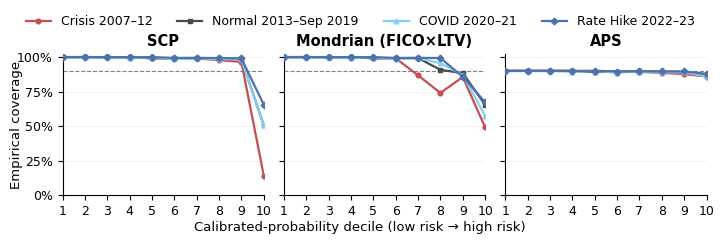

Figure 1 PNG saved → /content/drive/MyDrive/master_thesis/results/nb08/figures/fig1_score_decile_coverage.png
Figure 1 PDF saved → /content/drive/MyDrive/master_thesis/results/nb08/figures/fig1_score_decile_coverage.pdf


In [ ]:
# ── Figure 1: Coverage by calibrated-probability decile, method-centred ─────

N_DECILES = 10

# 1. Build the exact data behind the figure

decile_rows = []

# Only keep columns needed for this diagnostic.
# This materially reduces the temporary per-regime copy relative to copying df_pd.
plot_cols = ["p_hat_cal"] + [M_COLS[m] for m in AUDIT_METHODS]

for split in TEST_SPLITS:
    sub = (
        df_pd.loc[df_pd["split"].eq(split), plot_cols]
        .copy()
    )

    # Equal-frequency bins of calibrated probability within each regime.
    # duplicates="drop" preserves the upstream tie-handling convention.
    sub["score_decile"] = pd.qcut(
        sub["p_hat_cal"],
        q=N_DECILES,
        labels=False,
        duplicates="drop",
    )

    decile_index = sorted(
        int(d)
        for d in sub["score_decile"].dropna().unique()
    )

    # The current thesis result and Appendix E.5 assume ten realised bins.
    # Fail loudly if a future rerun changes that contract.
    assert decile_index == list(range(N_DECILES)), (
        f"{split}: expected {N_DECILES} realised score deciles, "
        f"found {len(decile_index)} ({decile_index}). "
        "Update the figure and Appendix E.5 if this data contract changes."
    )

    # Compute all three method-specific miscoverage rates in one groupby.
    decile_miscov = (
        sub.groupby("score_decile")[
            [M_COLS[m] for m in AUDIT_METHODS]
        ]
        .mean()
        .reindex(decile_index)
    )

    for method in AUDIT_METHODS:
        mc_col = M_COLS[method]

        miscov = decile_miscov[mc_col].to_numpy(dtype=float)
        cov = 1.0 - miscov

        for d, m, c in zip(decile_index, miscov, cov):
            decile_rows.append({
                "split": split,
                "method": method,
                "score_decile": d + 1,  # human-readable D1 ... D10
                "miscov_rate": float(m),
                "miscov_rate_pct": float(m * 100),
                "coverage_rate": float(c),
                "coverage_rate_pct": float(c * 100),
                "dev_from_nominal_miscov_pp": float((m - ALPHA) * 100),
            })

    del sub, decile_miscov


# Preserve the existing fig1_data schema for the following output cell
# and for consistency with the extracted notebook results.
fig1_data = (
    pd.DataFrame(decile_rows)
    .sort_values(["split", "method", "score_decile"])
    .reset_index(drop=True)
)

# Structural checks: 4 regimes × 3 methods × 10 deciles = 120 rows.
assert len(fig1_data) == (
    len(TEST_SPLITS) * len(AUDIT_METHODS) * N_DECILES
)

assert (
    fig1_data.groupby(["split", "method"])["score_decile"]
    .nunique()
    .eq(N_DECILES)
    .all()
)


# 2. Plot: one panel per method, one line per deployment regime

FIG_SPLIT_LABELS = {
    "test_subprime":  "Crisis 2007–12",
    "test_normal":    "Normal 2013–Sep 2019",
    "test_covid":     "COVID 2020–21",
    "test_rate_hike": "Rate Hike 2022–23",
}

FIG52_SPLIT_COLORS = {
    "test_subprime":  "#C44E52",
    "test_normal":    "#4A4A4A",
    "test_covid":     "#89CFF0",
    "test_rate_hike": "#4C72B0",
}

FIG_SPLIT_MARKERS = {
    "test_subprime":  "o",
    "test_normal":    "s",
    "test_covid":     "^",
    "test_rate_hike": "D",
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(7.0, 2.35),
    sharex=True,
    sharey=True,
)

for ax, method in zip(axes, AUDIT_METHODS):

    for split in TEST_SPLITS:
        plot_df = (
            fig1_data[
                (fig1_data["method"] == method)
                & (fig1_data["split"] == split)
            ]
            .sort_values("score_decile")
        )

        ax.plot(
            plot_df["score_decile"],
            plot_df["coverage_rate_pct"],
            color=FIG52_SPLIT_COLORS[split],
            linewidth=1.6,
            marker=FIG_SPLIT_MARKERS[split],
            markersize=3.4,
            label=FIG_SPLIT_LABELS[split],
            zorder=3,
        )

    # Nominal coverage reference.
    ax.axhline(
        NOMINAL_COV * 100,
        color="0.50",
        linestyle="--",
        linewidth=0.8,
        zorder=1,
    )

    ax.set_title(
        METHOD_LABELS[method],
        fontsize=10.5,
        fontweight="bold",
    )

    ax.set_xlim(1, N_DECILES)
    ax.set_ylim(0, 102)

    ax.set_xticks(range(1, N_DECILES + 1))
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.yaxis.set_major_formatter(
        mpl.ticker.PercentFormatter(xmax=100, decimals=0)
    )

    # Keep only the grid that aids coverage comparison.
    ax.grid(False)
    ax.grid(
        axis="y",
        alpha=0.18,
        linewidth=0.6,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Shared labels avoid repeating the same text three times.
fig.supylabel(
    "Empirical coverage",
    fontsize=9.5,
    x=0.0,
)

fig.supxlabel(
    "Calibrated-probability decile (low risk → high risk)",
    fontsize=9.5,
    y=0.035,
)

# One regime legend for the entire figure.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.015),
    ncol=4,
    frameon=False,
    fontsize=9,
)

# Compact horizontal layout for thesis use.
fig.subplots_adjust(
    left=0.075,
    right=0.995,
    bottom=0.20,
    top=0.80,
    wspace=0.10,
)

fig_path = FIG_DIR / "fig1_score_decile_coverage.png"
fig_pdf_path = fig_path.with_suffix(".pdf")

# Raster copy for notebook / quick inspection
fig.savefig(
    fig_path,
    bbox_inches="tight",
    dpi=FIG_DPI,
)

# Vector copy for the thesis
fig.savefig(
    fig_pdf_path,
    bbox_inches="tight",
)

plt.show()

print(f"Figure 1 PNG saved → {fig_path}")
print(f"Figure 1 PDF saved → {fig_pdf_path}")

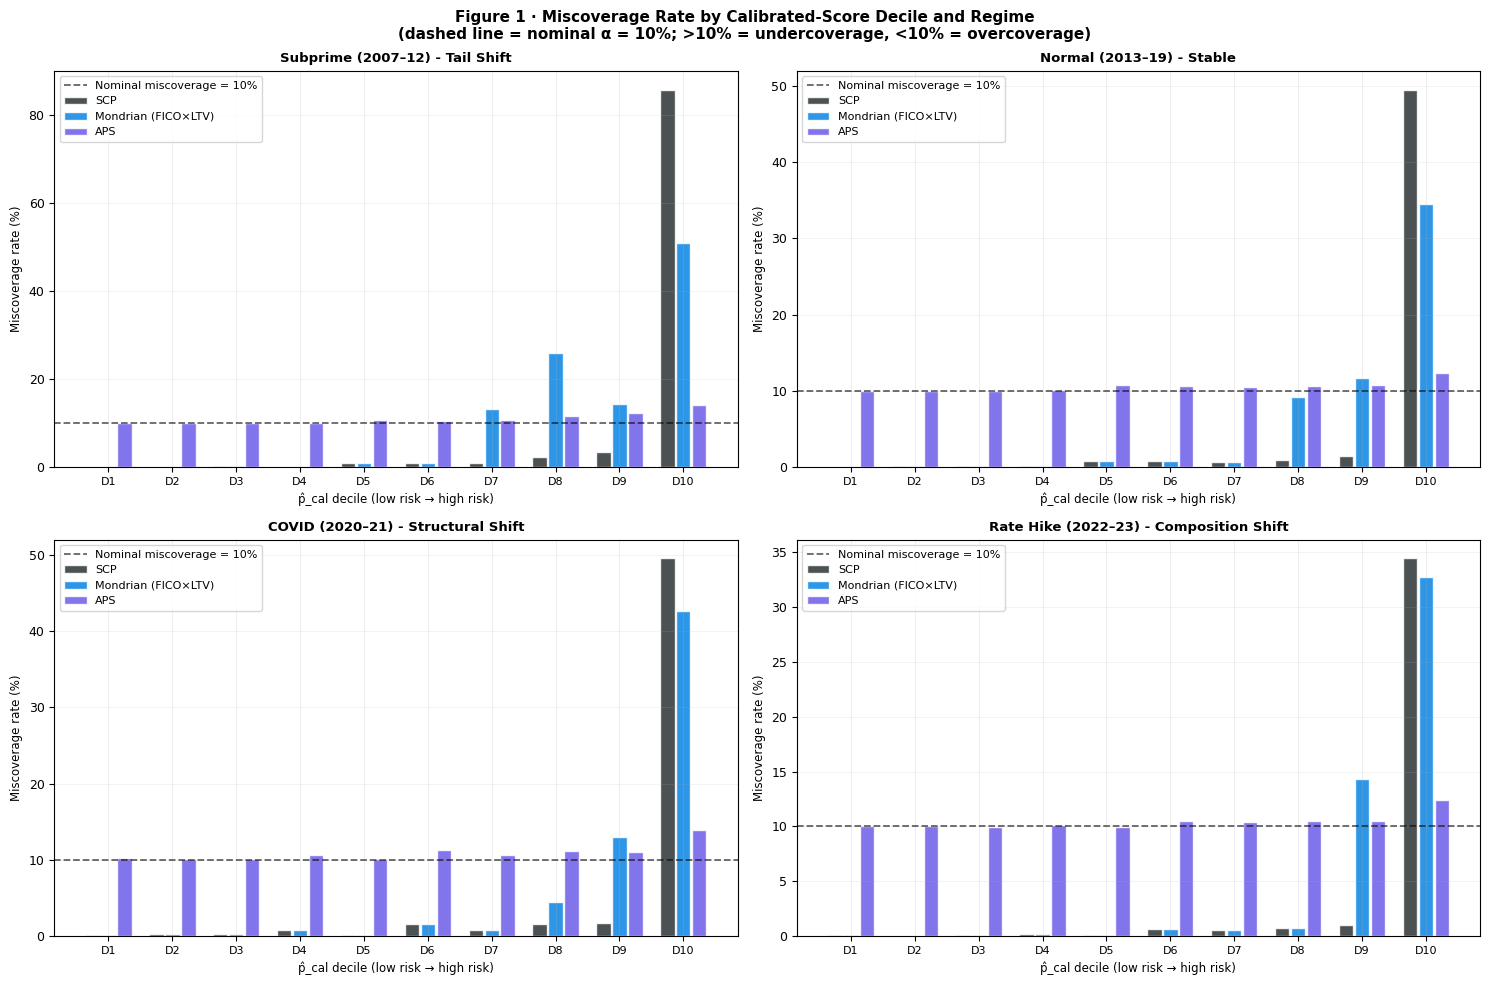

Figure 1 saved.


In [ ]:
# ── OLD Figure 1: Miscoverage rate by score decile and method ─────────────────
# Per-method miscoverage within p_hat_cal deciles.

N_DECILES = 10

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    "Figure 1 · Miscoverage Rate by Calibrated-Score Decile and Regime\n"
    "(dashed line = nominal α = 10%; >10% = undercoverage, <10% = overcoverage)",
    fontsize=11,
    fontweight="bold",
)

decile_rows = []

for ax, split in zip(axes.flatten(), TEST_SPLITS):
    sub = df_pd[df_pd["split"] == split].copy()

    # qcut can collapse bins when there are many ties; duplicates='drop' handles this safely
    sub["score_decile"] = pd.qcut(
        sub["p_hat_cal"],
        N_DECILES,
        labels=False,
        duplicates="drop",
    )

    decile_index = sorted(sub["score_decile"].dropna().unique().tolist())
    x = np.arange(len(decile_index))
    w = 0.25

    for k, method in enumerate(AUDIT_METHODS):
        mc_col = M_COLS[method]

        # Mean of the miscoverage indicator = empirical miscoverage rate
        dec_miscov = (
            sub.groupby("score_decile")[mc_col]
            .mean()
            .reindex(decile_index)
        )

        dec_cov = 1.0 - dec_miscov

        ax.bar(
            x + (k - 1) * w,
            dec_miscov.values * 100,
            width=w * 0.9,
            color=METHOD_COLORS[method],
            alpha=0.85,
            edgecolor="white",
            label=METHOD_LABELS[method],
        )

        # Store both coverage and miscoverage explicitly for downstream tables
        for d, miscov, cov in zip(decile_index, dec_miscov.values, dec_cov.values):
            decile_rows.append({
                "split": split,
                "method": method,
                "score_decile": int(d) + 1,  # human-readable D1..D10
                "miscov_rate": float(miscov),
                "miscov_rate_pct": float(miscov * 100),
                "coverage_rate": float(cov),
                "coverage_rate_pct": float(cov * 100),
                "dev_from_nominal_miscov_pp": float((miscov - ALPHA) * 100),
            })

    ax.axhline(
        ALPHA * 100,
        color="black",
        ls="--",
        lw=1.3,
        alpha=0.6,
        label="Nominal miscoverage = 10%",
    )
    ax.set_title(
        f"{SPLIT_LABELS[split]} - {SPLIT_MECH[split]}",
        fontsize=9.5,
        fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels([f"D{d+1}" for d in range(len(decile_index))], fontsize=8)
    ax.set_xlabel("p̂_cal decile (low risk → high risk)", fontsize=8.5)
    ax.set_ylabel("Miscoverage rate (%)", fontsize=8.5)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
fig.savefig(
    FIG_DIR / "fig1_score_decile_miscoverage.png",
    bbox_inches="tight",
    dpi=FIG_DPI,
)
plt.show()

# Save clean table behind Figure 1
fig1_data = (
    pd.DataFrame(decile_rows)
    .sort_values(["split", "method", "score_decile"])
    .reset_index(drop=True)
)

print("Figure 1 saved.")

In [ ]:
# ── Data behind OLD Figure 1 ───────────────────────────────────────────────────
print("Data behind Figure 1: score-decile miscoverage and coverage by method")
print(fig1_data.to_string(index=False))

Data behind Figure 1: score-decile miscoverage and coverage by method
         split            method  score_decile  miscov_rate  miscov_rate_pct  coverage_rate  coverage_rate_pct  dev_from_nominal_miscov_pp
    test_covid               aps             1     0.102162        10.216199       0.897838          89.783801                    0.216199
    test_covid               aps             2     0.101625        10.162485       0.898375          89.837515                    0.162485
    test_covid               aps             3     0.101302        10.130184       0.898698          89.869816                    0.130184
    test_covid               aps             4     0.106374        10.637400       0.893626          89.362600                    0.637400
    test_covid               aps             5     0.101109        10.110903       0.898891          89.889097                    0.110903
    test_covid               aps             6     0.112825        11.282478       0.887175     

In [ ]:
# ── Table 2: Baseline miscoverage by FICO×LTV and regime (sample) ────────

print("=== Baseline: Miscoverage by FICO×LTV group and regime (5% sample) ===\n")
baseline_rows = []

for split in TEST_SPLITS:
    sub = df_pd[df_pd["split"] == split]
    for cell in sorted(sub["fico_ltv_group"].dropna().unique()):
        if cell == "Sentinel":
            continue
        cell_sub = sub[sub["fico_ltv_group"] == cell]
        if len(cell_sub) < 100:
            continue
        row = {
            "split"   : split,
            "mechanism": SPLIT_MECH[split],
            "fico_ltv_group": cell,
            "n_sample": len(cell_sub),
            "pos_rate_pct": cell_sub["y"].mean() * 100,
            "empty_scp_pct": cell_sub["empty_scp"].mean() * 100,
        }
        for method in AUDIT_METHODS:
            mc_col = M_COLS[method]
            row[f"mc_{method}_pct"] = cell_sub[mc_col].mean() * 100
            row[f"dev_{method}_pp"] = row[f"mc_{method}_pct"] - (ALPHA * 100)
        baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows)

# Print compact summary
print(f"{'Cell':<25} {'Regime':<15} {'n':>8} {'SCP MC':>8} {'Mond MC':>9} {'APS MC':>8} {'empty':>7}")
print("-" * 82)
for _, r in baseline_df.sort_values(["split", "fico_ltv_group"]).iterrows():
    print(f"  {r['fico_ltv_group']:<23} {r['mechanism'][:12]:<14} "
          f"{r['n_sample']:>8,} "
          f"{r['mc_scp_pct']:>8.2f}% "
          f"{r['mc_mondrian_fico_ltv_pct']:>9.2f}% "
          f"{r['mc_aps_pct']:>8.2f}% "
          f"{r['empty_scp_pct']:>6.2f}%")

=== Baseline: Miscoverage by FICO×LTV group and regime (5% sample) ===

Cell                      Regime                 n   SCP MC   Mond MC   APS MC   empty
----------------------------------------------------------------------------------
  Near-Prime × High       Structural S    146,616    18.03%      9.03%    11.64%  16.13%
  Near-Prime × Low        Structural S   1,600,217     8.96%      8.57%    11.43%   7.58%
  Near-Prime × Moderate   Structural S    516,138    16.20%      8.56%    11.58%  14.53%
  Prime × High            Structural S    292,499     5.85%      5.52%    11.21%   4.60%
  Prime × Low             Structural S   5,772,056     2.02%      5.28%    10.58%   1.46%
  Prime × Moderate        Structural S   1,514,130     4.13%      4.89%    10.87%   3.22%
  Subprime × High         Structural S     26,587    39.65%      5.60%    10.59%  38.40%
  Subprime × Low          Structural S    165,897    26.04%      9.97%    11.90%  24.22%
  Subprime × Moderate     Structural S     

---
## Section 3 · Score-Alone vs Full-Feature Reliability Model

### The key diagnostic question

If a model trained **only on p̂_cal** achieves nearly the same AUROC for predicting
$M_i$ as the full model, the calibrated score captures nearly all discrimination
available to this diagnostic specification. If the full model improves materially,
the added subgroup or temporal variables contain incremental information about
realised miscoverage.

### Evaluation design: leave-one-regime-out

The diagnostic is evaluated **leave-one-regime-out**: train on three regime windows
and evaluate on the fourth, repeated across all four. This measures transfer to a
held-out regime rather than performance on a random mixture of the same regime
environments. It does not remove the panel's within-loan dependence across windows.

The comparison is intentionally diagnostic: AUROC is used to
measure how separable realised miscoverage events are from observed pre-outcome
features. A higher AUROC indicates stronger local structure in the failure pattern,
not a better conformal method.

This supervised treatment of realised miscoverage as a classification target follows
recent conditional-coverage diagnostics that cast local-validity assessment as a
supervised-learning problem (Braun et al., 2025; Zhou et al., 2026).


In [ ]:
# ── 3.1 · Leave-one-regime-out AUROC: score-only vs full-feature ─────────────
#
# For each (method, held-out regime), compare:
#   - Score-only model: LightGBM with only p_hat_cal as feature
#   - Full model      : LightGBM with all 7 features

LOSO_PARAMS = {
    "objective"  : "binary",
    "metric"     : "auc",
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves"  : 31,
    "min_child_samples": 200,
    "subsample"  : 0.8,
    "colsample_bytree": 0.8,
    "n_jobs"     : -1,
    "verbose"    : -1,
    "random_state": SAMPLE_SEED,
}

loso_results = []

for method in AUDIT_METHODS:
    mc_col = M_COLS[method]
    print(f"\n  Method: {METHOD_LABELS[method]}")

    for held_out in TEST_SPLITS:
        train_splits = [s for s in TEST_SPLITS if s != held_out]
        train_df     = df_pd[df_pd["split"].isin(train_splits)]
        test_df      = df_pd[df_pd["split"] == held_out]

        y_train = train_df[mc_col].values
        y_test  = test_df[mc_col].values

        # Skip if too few positives in train or test
        if y_train.sum() < 100 or y_test.sum() < 100:
            print(f"    Held-out {held_out}: too few positives, skipping")
            continue

        for feat_set, feat_cols in [("score_only", FEATURE_COLS_SCORE),
                                     ("full"      , FEATURE_COLS_FULL)]:
            X_train = train_df[feat_cols].values.astype(np.float32)
            X_test  = test_df[feat_cols].values.astype(np.float32)

            # Early stopping uses a held-out slice of the training data
            # (last 10% of train rows by index), not the test fold.
            # Using the test fold as eval_set for early stopping would let
            # the held-out regime influence the number of boosting rounds,
            # violating the LOSO principle.
            n_val = max(1, int(0.10 * len(train_df)))
            X_val, y_val = X_train[-n_val:], y_train[-n_val:]
            X_tr,  y_tr  = X_train[:-n_val], y_train[:-n_val]

            model = lgb.LGBMClassifier(**LOSO_PARAMS)
            model.fit(X_tr, y_tr,
                      eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(30, verbose=False),
                                 lgb.log_evaluation(period=-1)])

            y_prob  = model.predict_proba(X_test)[:, 1]
            auroc   = roc_auc_score(y_test, y_prob)
            auprc   = average_precision_score(y_test, y_prob)

            loso_results.append({
                "method"       : method,
                "held_out"     : held_out,
                "mechanism"    : SPLIT_MECH[held_out],
                "feat_set"     : feat_set,
                "n_train"      : len(train_df),
                "n_test"       : len(test_df),
                "n_pos_test"   : int(y_test.sum()),
                "auroc"        : auroc,
                "auprc"        : auprc,
            })
            print(f"    Held-out {SPLIT_LABELS[held_out]:<22} [{feat_set:<10}]  "
                  f"AUROC={auroc:.4f}  AUPRC={auprc:.4f}")

loso_df = pd.DataFrame(loso_results)


  Method: SCP
    Held-out Subprime (2007–12)     [score_only]  AUROC=0.9973  AUPRC=0.9856
    Held-out Subprime (2007–12)     [full      ]  AUROC=0.9972  AUPRC=0.9863
    Held-out Normal (2013–19)       [score_only]  AUROC=0.9953  AUPRC=0.9724
    Held-out Normal (2013–19)       [full      ]  AUROC=0.9957  AUPRC=0.9746
    Held-out COVID (2020–21)        [score_only]  AUROC=0.9921  AUPRC=0.9553
    Held-out COVID (2020–21)        [full      ]  AUROC=0.9930  AUPRC=0.9597
    Held-out Rate Hike (2022–23)    [score_only]  AUROC=0.9949  AUPRC=0.9635
    Held-out Rate Hike (2022–23)    [full      ]  AUROC=0.9948  AUPRC=0.9640

  Method: Mondrian (FICO×LTV)
    Held-out Subprime (2007–12)     [score_only]  AUROC=0.9369  AUPRC=0.6619
    Held-out Subprime (2007–12)     [full      ]  AUROC=0.9962  AUPRC=0.9829
    Held-out Normal (2013–19)       [score_only]  AUROC=0.9560  AUPRC=0.6787
    Held-out Normal (2013–19)       [full      ]  AUROC=0.9950  AUPRC=0.9726
    Held-out COVID (2020–21)  

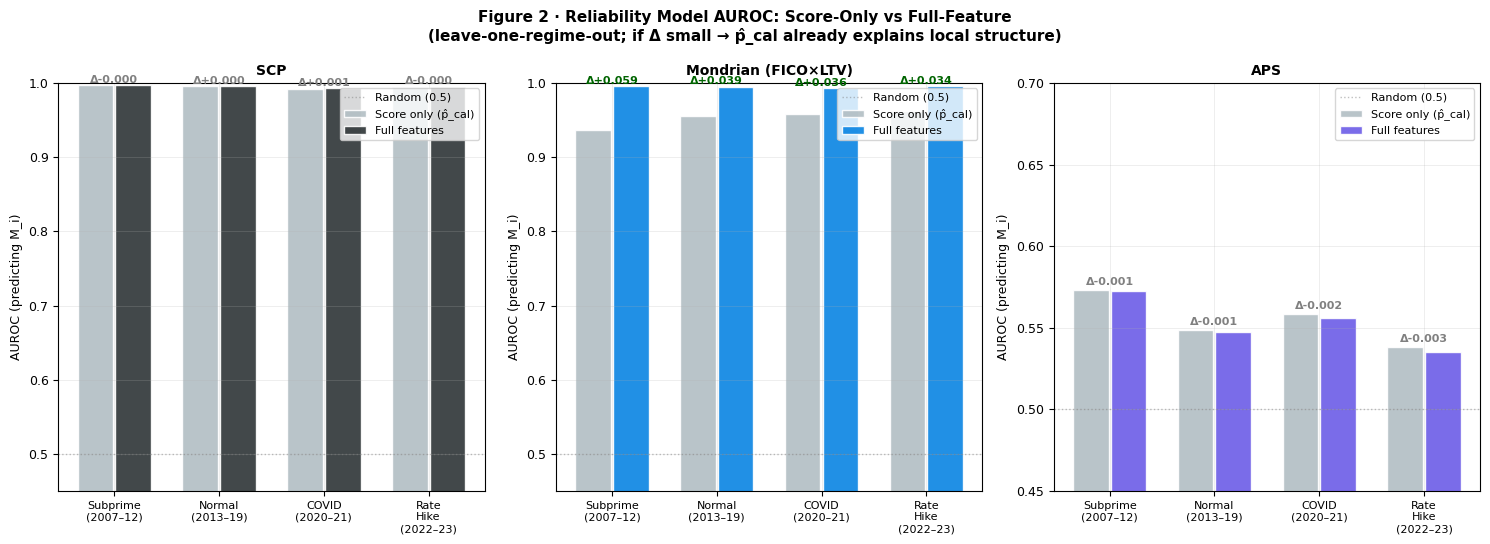

Figure 2 saved.


In [ ]:
# ── Figure 2: Score-only vs full-feature AUROC comparison ────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(
    "Figure 2 · Reliability Model AUROC: Score-Only vs Full-Feature\n"
    "(leave-one-regime-out; if Δ small → p̂_cal already explains local structure)",
    fontsize=11, fontweight="bold"
)

for ax, method in zip(axes, AUDIT_METHODS):
    mdf     = loso_df[loso_df["method"] == method]
    so_aucs = [mdf[(mdf["held_out"]==s) & (mdf["feat_set"]=="score_only")]["auroc"].values
               for s in TEST_SPLITS]
    fu_aucs = [mdf[(mdf["held_out"]==s) & (mdf["feat_set"]=="full")]["auroc"].values
               for s in TEST_SPLITS]

    so_vals = [v[0] if len(v)>0 else np.nan for v in so_aucs]
    fu_vals = [v[0] if len(v)>0 else np.nan for v in fu_aucs]
    x       = np.arange(len(TEST_SPLITS))

    ax.bar(x - 0.18, so_vals, 0.34, label="Score only (p̂_cal)",
           color="#b2bec3", alpha=0.9, edgecolor="white")
    ax.bar(x + 0.18, fu_vals, 0.34, label="Full features",
           color=METHOD_COLORS[method], alpha=0.9, edgecolor="white")

    # Annotate Δ AUROC
    for i, (sv, fv) in enumerate(zip(so_vals, fu_vals)):
        if not (np.isnan(sv) or np.isnan(fv)):
            delta = fv - sv
            ax.annotate(f"Δ{delta:+.3f}",
                        xy=(x[i], max(sv, fv) + 0.003),
                        ha="center", fontsize=8, fontweight="bold",
                        color="darkgreen" if delta > 0.01 else "grey")

    ax.axhline(0.5, color="grey", ls=":", lw=1, alpha=0.5, label="Random (0.5)")
    ax.set_xticks(x)
    ax.set_xticklabels([SPLIT_LABELS[s].replace(" ", "\n") for s in TEST_SPLITS],
                       fontsize=8)
    ax.set_ylim(0.45, min(1.0, max([v for v in fu_vals if not np.isnan(v)] + [0.65]) + 0.05))
    ax.set_ylabel("AUROC (predicting M_i)", fontsize=9)
    ax.set_title(f"{METHOD_LABELS[method]}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_loso_auroc_comparison.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()

print("Figure 2 saved.")

In [ ]:
# ── Data behind Figure 2 ────────────────────────────────────────────────────
fig2_data = (
    loso_df.pivot_table(index=["method", "held_out"], columns="feat_set", values="auroc")
           .reset_index()
           .rename(columns={"held_out": "split"})
)
fig2_data["delta_full_minus_score_only"] = fig2_data.get("full", np.nan) - fig2_data.get("score_only", np.nan)
fig2_data["method_label"] = fig2_data["method"].map(METHOD_LABELS)
fig2_data["split_label"] = fig2_data["split"].map(SPLIT_LABELS)
fig2_data = fig2_data[[
    "method", "method_label", "split", "split_label",
    "score_only", "full", "delta_full_minus_score_only"
]]

fig2_data.to_csv(NB08_OUT_DIR / "nb08_loso_auroc.csv", index=False)

print("Data behind Figure 2: score-only vs full-feature AUROC comparison")
print(fig2_data.to_string(index=False))

Data behind Figure 2: score-only vs full-feature AUROC comparison
           method        method_label          split         split_label  score_only     full  delta_full_minus_score_only
              aps                 APS     test_covid     COVID (2020–21)    0.558506 0.556114                    -0.002391
              aps                 APS    test_normal    Normal (2013–19)    0.548741 0.547439                    -0.001303
              aps                 APS test_rate_hike Rate Hike (2022–23)    0.538096 0.535021                    -0.003075
              aps                 APS  test_subprime  Subprime (2007–12)    0.573252 0.572734                    -0.000518
mondrian_fico_ltv Mondrian (FICO×LTV)     test_covid     COVID (2020–21)    0.957514 0.993321                     0.035808
mondrian_fico_ltv Mondrian (FICO×LTV)    test_normal    Normal (2013–19)    0.956049 0.995048                     0.039000
mondrian_fico_ltv Mondrian (FICO×LTV) test_rate_hike Rate Hike (2022–23) 

### Interpreting local-reliability AUROC

AUROC is a descriptive measure of how separable realised miscoverage events are
within each method. Because the miscoverage-generating mechanisms differ across
methods, neither AUROC levels nor score-only → full increments are treated as a
common cross-method effect size.

**SCP.** Miscoverage is thresholded on the true-label nonconformity score. The
calibrated probability alone nevertheless predicts it almost perfectly here, and
the full specification adds essentially no discrimination. The result therefore
shows that score position captures nearly all observable separation in this audit. It is not independent evidence of a rich high-dimensional failure mechanism.

**Mondrian.** Cell-specific thresholds break the single global score relationship.
The improvement from score-only to the full specification is therefore consistent
with residual failure being cell-structured, including structure induced by the
cell-specific calibration rule itself.

**APS.** The randomised APS score adds a component of realised miscoverage that
covariates cannot predict. Its near-random reliability-model AUROC therefore does
not by itself establish uniform coverage. The complementary score-band diagnostic
in §7.2 shows the remaining weakness more directly: APS miscoverage is higher for
`p_hat_cal >= 5%` than below 5% in every regime.

**Primary interpretation:** AUROC and its score-only → full change are descriptive
within-method diagnostics; they are not interpreted as a common effect-size scale
across methods.

---
## Section 4 · Full Reliability Model and Concentration Curves

### Concentration curves: the core local-reliability diagnostic

After fitting the full-feature reliability model, its most important output is not
a single AUROC but a concentration curve: sorting test observations by predicted
miscoverage risk and asking how efficiently the model identifies the
truly miscovered observations.

Formally, let $\hat r_i$ denote the reliability model's predicted miscoverage risk for observation $i$, and let $\sigma$ sort observations by decreasing predicted
risk: $\hat r_{\sigma(1)} \geq \hat r_{\sigma(2)} \geq \cdots \geq
\hat r_{\sigma(n)}$.. The concentration curve plots, for each fraction $f \in [0,1]$
of the highest-risk observations, the share of total realised miscoverage they account for:

$$\text{Capture}(f) = \frac{\displaystyle\sum_{k=1}^{\lfloor fn \rfloor} M_{\sigma(k)}}{\displaystyle\sum_{i=1}^{n} M_i}$$

with $\text{Capture}(0) = 0$ by convention. The random baseline satisfies
$\text{Capture}(f) = f$ for all $f$, giving $\text{AUC} = \tfrac{1}{2}$.
A steep curve (AUC $\gg \tfrac{1}{2}$) indicates strongly concentrated local failure;
a near-diagonal curve indicates diffuse, weakly structured failure.

If miscoverage is **locally structured**, the curve rises steeply - a small fraction
of high-risk observations explains a large fraction of all miscoverage events.
If miscoverage is **uniformly distributed**, the curve rises linearly (AUC = 0.5).

This is a descriptive cumulative-gain diagnostic for realised miscoverage events.
It is directly interpretable without adding a new conformal method: if the curve
is steep, miscoverage is concentrated among observations that the reliability model
ranks as high risk; if it is close to diagonal, miscoverage is comparatively diffuse.

### Feature importance interpretation

LightGBM gain importance is used descriptively to show which variables the fitted
reliability model uses. Because the FICO tier, LTV bucket, and crossed FICO×LTV
encodings overlap, their gains are also reported as an aggregate taxonomy-related
contribution. Gain importance is neither a causal attribution nor a test that the
predefined taxonomy is sufficient; it is supporting evidence about the structure
used by this fitted diagnostic model.


In [ ]:
# ── 4.1 · Train final pooled reliability models ──────────────────────────────

from sklearn.model_selection import train_test_split

FINAL_PARAMS = {
    "objective"    : "binary",
    "metric"       : "auc",
    "n_estimators" : 500,
    "learning_rate": 0.05,
    "num_leaves"   : 63,
    "min_child_samples": 500,   # conservative - prevents overfitting on large dataset
    "subsample"    : 0.8,
    "colsample_bytree": 0.9,
    "reg_alpha"    : 0.1,
    "reg_lambda"   : 1.0,
    "n_jobs"       : -1,
    "verbose"      : -1,
    "random_state" : SAMPLE_SEED,
}

# Year-based holdout (not chronological): train on the listed years;
# evaluate on 2019, 2022 and 2023.
TRAIN_YEARS = [2007, 2008, 2009, 2010, 2011, 2012,   # subprime
               2013, 2014, 2015, 2016, 2017, 2018,   # normal (most)
               2020, 2021]                            # covid
EVAL_YEARS  = [2019, 2022, 2023]                     # normal tail + rate-hike

train_mask = df_pd["obs_year"].isin(TRAIN_YEARS)
eval_mask  = ~train_mask

df_pd["is_eval"] = eval_mask.values

print(f"Train set: {train_mask.sum():,} rows | Eval set: {eval_mask.sum():,} rows")
print(f"  Train years: {sorted(TRAIN_YEARS)}")
print(f"  Eval  years: {sorted(EVAL_YEARS)}")
print()

final_models = {}
final_evals  = {}

for method in AUDIT_METHODS:
    mc_col = M_COLS[method]
    X_tr   = df_pd.loc[train_mask, FEATURE_COLS_FULL].values.astype(np.float32)
    y_tr   = df_pd.loc[train_mask, mc_col].values
    X_ev   = df_pd.loc[eval_mask,  FEATURE_COLS_FULL].values.astype(np.float32)
    y_ev   = df_pd.loc[eval_mask,  mc_col].values

    # Early-stopping validation slice carved from the TRAIN years only, so the
    # eval-year rows never influence the number of boosting rounds. Stratified on
    # the miscoverage label to hold the positive rate stable in the slice.
    _strat = y_tr if (y_tr.sum() >= 50 and (len(y_tr) - y_tr.sum()) >= 50) else None
    X_fit, X_es, y_fit, y_es = train_test_split(
        X_tr, y_tr, test_size=0.10, random_state=SAMPLE_SEED, stratify=_strat
    )

    model = lgb.LGBMClassifier(**FINAL_PARAMS)
    model.fit(X_fit, y_fit,
              eval_set=[(X_es, y_es)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])

    y_prob = model.predict_proba(X_ev)[:, 1]
    auroc  = roc_auc_score(y_ev, y_prob)
    auprc  = average_precision_score(y_ev, y_prob)

    final_models[method] = model
    final_evals[method]  = {
        "y_true": y_ev, "y_prob": y_prob,
        "auroc": auroc, "auprc": auprc,
        "obs_idx": df_pd.index[eval_mask].tolist(),
    }
    print(f"  {METHOD_LABELS[method]:<24}  AUROC={auroc:.4f}  AUPRC={auprc:.4f}  "
          f"n_trees={model.n_estimators_}")

# Add predicted risk to full DataFrame
for method in AUDIT_METHODS:
    risk_col = f"risk_{method}"
    X_all    = df_pd[FEATURE_COLS_FULL].values.astype(np.float32)
    df_pd[risk_col] = final_models[method].predict_proba(X_all)[:, 1]
    print(f"  Added predicted-risk column: {risk_col}")

Train set: 75,045,508 rows | Eval set: 19,824,180 rows
  Train years: [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2020, 2021]
  Eval  years: [2019, 2022, 2023]

  SCP                       AUROC=0.9914  AUPRC=0.9477  n_trees=500
  Mondrian (FICO×LTV)       AUROC=0.9935  AUPRC=0.9630  n_trees=500
  APS                       AUROC=0.5497  AUPRC=0.1803  n_trees=492
  Added predicted-risk column: risk_scp
  Added predicted-risk column: risk_mondrian_fico_ltv
  Added predicted-risk column: risk_aps


/tmp/ipykernel_1720/3970305289.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_conc = np.trapz(captures, FRACS)


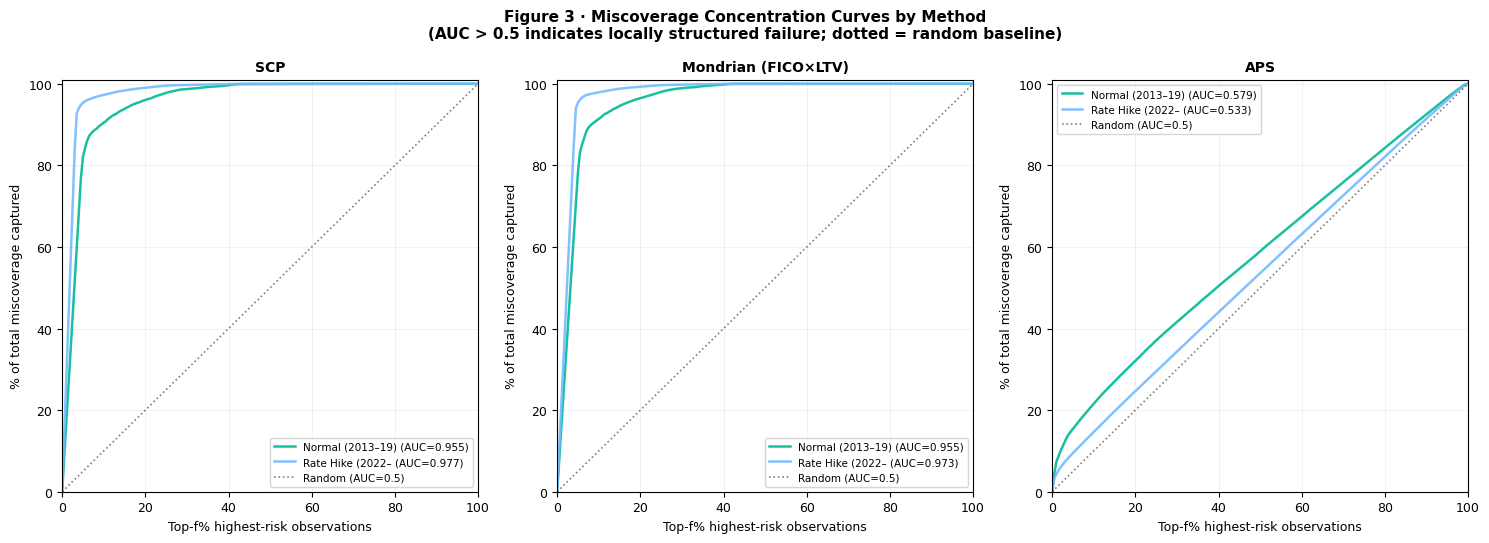

Figure 3 saved.


In [ ]:
# ── Figure 3: Concentration curves ───────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(
    "Figure 3 · Miscoverage Concentration Curves by Method\n"
    "(AUC > 0.5 indicates locally structured failure; dotted = random baseline)",
    fontsize=11, fontweight="bold"
)

conc_rows = []
FRACS = np.linspace(0, 1, 201)

for ax, method in zip(axes, AUDIT_METHODS):
    mc_col   = M_COLS[method]
    risk_col = f"risk_{method}"

    # Per-regime concentration curves - restricted to eval-year observations
    # to ensure predicted risk is out-of-sample throughout.
    # Regimes with no eval-year observations (e.g. full Subprime 2007-12 / COVID
    # 2020-21) will produce empty subsets and are skipped via the total_mc check.
    for split in TEST_SPLITS:
        sub      = df_pd[(df_pd["split"] == split) & (df_pd["is_eval"])].copy()
        y_true   = sub[mc_col].values
        y_risk   = sub[risk_col].values

        if y_true.sum() < 10:
            continue

        # Sort by descending predicted risk
        order    = np.argsort(-y_risk)
        y_sorted = y_true[order]

        # Capture fraction at each top-f threshold
        cumsum   = np.cumsum(y_sorted)
        total_mc = y_true.sum()
        captures = [0.0]   # Capture(0) = 0 by definition
        for f in FRACS[1:]:
            top_n = max(1, int(f * len(y_true)))
            captures.append(cumsum[top_n - 1] / total_mc if total_mc > 0 else 0.0)

        # AUC of concentration curve (trapezoid rule)
        auc_conc = np.trapz(captures, FRACS)

        ax.plot(FRACS * 100, np.array(captures) * 100,
                color=SPLIT_COLORS[split], lw=1.8, alpha=0.9,
                label=f"{SPLIT_LABELS[split][:16]} (AUC={auc_conc:.3f})")

        # Store for CSV
        for f, c in zip(FRACS[::10], captures[::10]):
            conc_rows.append({
                "method": method, "split": split,
                "frac_pct": float(f*100), "capture_pct": float(c*100),
                "auc_conc": auc_conc,
            })

    ax.plot(FRACS * 100, FRACS * 100, "k:", lw=1.2, alpha=0.5, label="Random (AUC=0.5)")
    ax.set_xlabel("Top-f% highest-risk observations", fontsize=9)
    ax.set_ylabel("% of total miscoverage captured", fontsize=9)
    ax.set_title(f"{METHOD_LABELS[method]}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7.5)
    ax.set_xlim(0, 100); ax.set_ylim(0, 101)
    ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_concentration_curves.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 3 saved.")

In [ ]:
# ── Data behind Figure 3 ────────────────────────────────────────────────────
fig3_data = pd.DataFrame(conc_rows).sort_values(
    ["method", "split", "frac_pct"]
).reset_index(drop=True)

fig3_auc_summary = (
    fig3_data[["method", "split", "auc_conc"]]
    .drop_duplicates()
    .assign(method_label=lambda d: d["method"].map(METHOD_LABELS),
            split_label=lambda d: d["split"].map(SPLIT_LABELS))
    [["method", "method_label", "split", "split_label", "auc_conc"]]
    .sort_values(["method", "split"])
    .reset_index(drop=True)
)

print("Data behind Figure 3: concentration curve points")
print(fig3_data.to_string(index=False))
print("\nAUC summary for Figure 3")
print(fig3_auc_summary.to_string(index=False))

Data behind Figure 3: concentration curve points
           method          split  frac_pct  capture_pct  auc_conc
              aps    test_normal       0.0     0.000000  0.579110
              aps    test_normal       5.0    15.435765  0.579110
              aps    test_normal      10.0    21.613991  0.579110
              aps    test_normal      15.0    27.019468  0.579110
              aps    test_normal      20.0    32.091154  0.579110
              aps    test_normal      25.0    37.079723  0.579110
              aps    test_normal      30.0    41.617270  0.579110
              aps    test_normal      35.0    46.020435  0.579110
              aps    test_normal      40.0    50.410217  0.579110
              aps    test_normal      45.0    54.657323  0.579110
              aps    test_normal      50.0    58.943633  0.579110
              aps    test_normal      55.0    63.244078  0.579110
              aps    test_normal      60.0    67.467248  0.579110
              aps    test_n

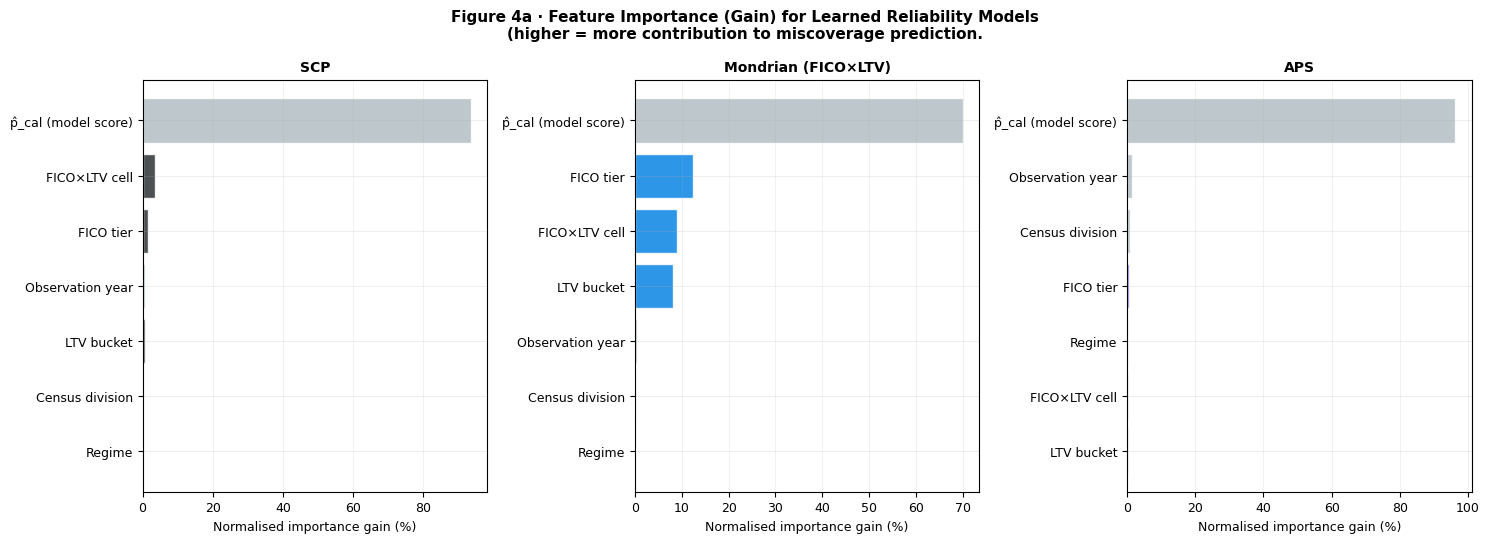

Figure 12a saved.


In [ ]:
# ── Figure 4a: Feature importance for local reliability models ──────────────
#
# LightGBM gain importance, interpreted descriptively.
# FICO/LTV-related gains are aggregated because the encodings overlap.
# Importance indicates use by the fitted diagnostic model, not causality or taxonomy sufficiency.

FEAT_NAMES = {
    "p_hat_cal"     : "p̂_cal (model score)",
    "fico_tier_enc" : "FICO tier",
    "ltv_bucket_enc": "LTV bucket",
    "fico_ltv_enc"  : "FICO×LTV cell",
    "census_enc"    : "Census division",
    "obs_year"      : "Observation year",
    "regime_enc"    : "Regime",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(
    "Figure 4a · Feature Importance (Gain) for Learned Reliability Models\n"
    "(higher = more contribution to miscoverage prediction.",
    fontsize=11, fontweight="bold"
)

fi_rows = []
for ax, method in zip(axes, AUDIT_METHODS):
    model    = final_models[method]
    gains    = model.booster_.feature_importance(importance_type="gain")
    fi_dict  = dict(zip(FEATURE_COLS_FULL, gains))
    fi_norm  = {k: v / max(gains.sum(), 1e-9) for k, v in fi_dict.items()}

    # Sort by importance
    sorted_feats = sorted(fi_norm, key=lambda x: -fi_norm[x])
    labels = [FEAT_NAMES.get(f, f) for f in sorted_feats]
    vals   = [fi_norm[f] * 100 for f in sorted_feats]

    colors_fi = [METHOD_COLORS[method] if f in ("fico_ltv_enc", "fico_tier_enc", "ltv_bucket_enc")
                 else "#b2bec3" for f in sorted_feats]

    ax.barh(range(len(sorted_feats)), vals, color=colors_fi, alpha=0.85, edgecolor="white")
    ax.set_yticks(range(len(sorted_feats)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Normalised importance gain (%)", fontsize=9)
    ax.set_title(f"{METHOD_LABELS[method]}", fontsize=10, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)

    for i, (feat, val) in enumerate(zip(sorted_feats, vals)):
        fi_rows.append({
            "method": method, "feature": feat,
            "feature_label": FEAT_NAMES.get(feat, feat),
            "gain_pct": val,
        })

fig.tight_layout()
fig.savefig(FIG_DIR / "fig12a_feature_importance.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
pd.DataFrame(fi_rows).to_csv(NB08_OUT_DIR / "nb08_feature_importance.csv", index=False)
print("Figure 12a saved.")

In [ ]:
# ── Data behind Figure 4a ───────────────────────────────────────────────────
fig4a_data = pd.DataFrame(fi_rows).sort_values(
    ["method", "gain_pct"], ascending=[True, False]
).reset_index(drop=True)

print("Data behind Figure 4a: normalized feature-importance gain by method")
print(fig4a_data.to_string(index=False))

Data behind Figure 4a: normalized feature-importance gain by method
           method        feature        feature_label  gain_pct
              aps      p_hat_cal p̂_cal (model score) 96.241096
              aps       obs_year     Observation year  1.391344
              aps     census_enc      Census division  0.733031
              aps  fico_tier_enc            FICO tier  0.695221
              aps     regime_enc               Regime  0.394444
              aps   fico_ltv_enc        FICO×LTV cell  0.370325
              aps ltv_bucket_enc           LTV bucket  0.174539
mondrian_fico_ltv      p_hat_cal p̂_cal (model score) 69.997012
mondrian_fico_ltv  fico_tier_enc            FICO tier 12.335535
mondrian_fico_ltv   fico_ltv_enc        FICO×LTV cell  8.914243
mondrian_fico_ltv ltv_bucket_enc           LTV bucket  8.091718
mondrian_fico_ltv       obs_year     Observation year  0.458015
mondrian_fico_ltv     census_enc      Census division  0.160738
mondrian_fico_ltv     regime_enc    

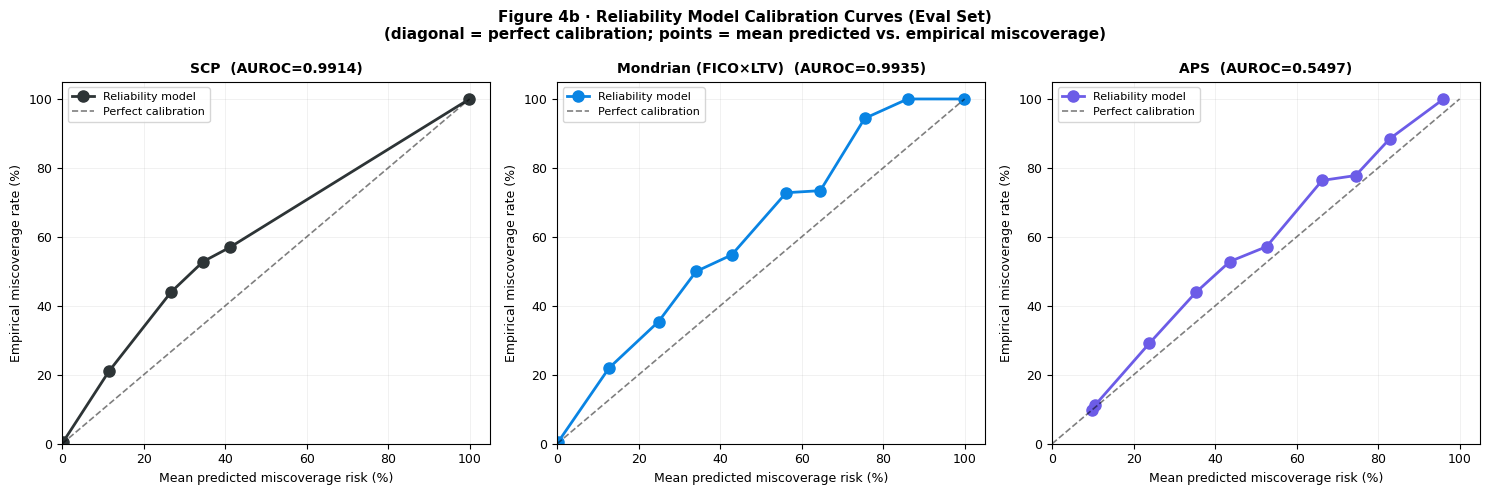

Figure 4b saved.
           method        method_label   n_eval  n_pos_eval    auroc    auprc
              scp                 SCP 19824180      814751 0.991390 0.947676
mondrian_fico_ltv Mondrian (FICO×LTV) 19824180     1007454 0.993474 0.962975
              aps                 APS 19824180     2125217 0.549730 0.180343


In [ ]:
# ── Figure 4b: Reliability calibration curves ────────────────────────────
#
# A reliability model should itself be well-calibrated: if it predicts 30%
# miscoverage risk for a group of observations, approximately 30% of them
# should actually be miscovered. Poor calibration of the reliability model
# would indicate overconfident or underconfident risk predictions.
#
# Reference: reliability diagrams (calibration curves) are the standard
# diagnostic for probability calibration (Guo et al. 2017).

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Figure 4b · Reliability Model Calibration Curves (Eval Set)\n"
    "(diagonal = perfect calibration; points = mean predicted vs. empirical miscoverage)",
    fontsize=11, fontweight="bold"
)

for ax, method in zip(axes, AUDIT_METHODS):
    mc_col  = M_COLS[method]
    ev      = final_evals[method]
    y_true  = ev["y_true"]
    y_prob  = ev["y_prob"]

    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ax.plot(mean_pred * 100, frac_pos * 100,
            "o-", color=METHOD_COLORS[method], lw=2, ms=8, label="Reliability model")
    ax.plot([0, 100], [0, 100], "k--", lw=1.2, alpha=0.5, label="Perfect calibration")

    ax.set_xlabel("Mean predicted miscoverage risk (%)", fontsize=9)
    ax.set_ylabel("Empirical miscoverage rate (%)", fontsize=9)
    ax.set_title(f"{METHOD_LABELS[method]}  (AUROC={ev['auroc']:.4f})",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 105); ax.set_ylim(0, 105)
    ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig4b_reliability_calibration.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 4b saved.")

# ── Save reliability model summary ──────────────────────────────────────────
rel_summary = []
for method in AUDIT_METHODS:
    ev = final_evals[method]
    rel_summary.append({
        "method" : method, "method_label": METHOD_LABELS[method],
        "n_eval" : len(ev["y_true"]),
        "n_pos_eval": int(ev["y_true"].sum()),
        "auroc"  : ev["auroc"],
        "auprc"  : ev["auprc"],
    })
rel_df = pd.DataFrame(rel_summary)
print(rel_df.to_string(index=False))

In [ ]:
# ── Data behind Figure 4b ───────────────────────────────────────────────────
fig4b_rows = []
for method in AUDIT_METHODS:
    ev = final_evals[method]
    frac_pos, mean_pred = calibration_curve(ev["y_true"], ev["y_prob"], n_bins=10)
    for bin_idx, (mp, fp) in enumerate(zip(mean_pred, frac_pos), start=1):
        fig4b_rows.append({
            "method": method,
            "method_label": METHOD_LABELS[method],
            "bin": bin_idx,
            "mean_pred_pct": mp * 100,
            "empirical_mc_rate_pct": fp * 100,
            "auroc": ev["auroc"],
            "auprc": ev["auprc"],
            "n_eval": len(ev["y_true"]),
            "n_pos_eval": int(np.sum(ev["y_true"])),
        })

fig4b_data = pd.DataFrame(fig4b_rows).sort_values(["method", "bin"]).reset_index(drop=True)

print("Data behind Figure 4b: calibration-curve points")
print(fig4b_data.to_string(index=False))

Data behind Figure 4b: calibration-curve points
           method        method_label  bin  mean_pred_pct  empirical_mc_rate_pct    auroc    auprc   n_eval  n_pos_eval
              aps                 APS    1       9.684984               9.740300 0.549730 0.180343 19824180     2125217
              aps                 APS    2      10.546773              11.199628 0.549730 0.180343 19824180     2125217
              aps                 APS    3      23.861188              29.128486 0.549730 0.180343 19824180     2125217
              aps                 APS    4      35.244430              43.864513 0.549730 0.180343 19824180     2125217
              aps                 APS    5      43.621510              52.855424 0.549730 0.180343 19824180     2125217
              aps                 APS    6      52.608020              57.162193 0.549730 0.180343 19824180     2125217
              aps                 APS    7      66.250311              76.365663 0.549730 0.180343 19824180     

---
## Section 5 · Shallow-Tree Worst-Segment Discovery

### Purpose: summarise the local pockets

The LightGBM diagnostic measures separability and feature use. The shallow
decision tree instead produces a compact segmentation for describing the
resulting reliability pockets.

A depth-3 CART tree (Breiman et al., 1984) produces at most eight leaves.
I summarise them by support, empirical miscoverage, mean calibrated probability,
and dominant borrower-risk and regime composition. Numeric splits on
label-encoded cell or census variables are implementation partitions rather
than economically ordered cut-offs.

The resulting segments are not new conformal calibration groups and do not create
additional validity guarantees. They are descriptive audit segments used to name
where realised undercoverage or overcoverage is most concentrated.

### Segment evaluation metrics

For each discovered segment:
- **Support:** fraction of observations falling in the segment
- **Empirical miscoverage:** actual M_i rate in the segment
- **Deviation from nominal:** empirical rate - α
- **Overlap with FICO×LTV:** whether the segment aligns with predefined cells


In [ ]:
# ── 5.1 · Fit shallow decision trees per method ────────────────────────────
#
# Depth-3 tree on the audit feature set excluding regime_enc, fitted on pooled audit rows.

# Features for tree: integer-encoded categorical variables (ordinal for FICO/LTV,
# label-encoded for cell and census). Shallow trees split on thresholds like
# "fico_tier_enc <= 1" which are directly readable via the FICO_ORDER / LTV_ORDER
# dicts defined in §1.4.
#
# regime_enc is intentionally excluded so the depth-3 tree cannot use the
# pre-assigned regime categories directly as candidate splits. obs_year remains
# available, so temporal structure can still be discovered without hard-coding
# the regime partition. No counterfactual tree including regime_enc is fitted here.
TREE_FEATURES = ["p_hat_cal", "fico_tier_enc", "ltv_bucket_enc",
                 "fico_ltv_enc", "census_enc", "obs_year"]

MIN_SAMPLES_LEAF_FRAC = 0.005   # at least 0.5% of pooled audit rows per leaf

trees = {}
print("Fitting depth-3 segment-discovery trees...")
for method in AUDIT_METHODS:
    mc_col = M_COLS[method]
    X_all  = df_pd[TREE_FEATURES].values.astype(np.float32)
    y_all  = df_pd[mc_col].values
    min_leaf = max(50, int(MIN_SAMPLES_LEAF_FRAC * len(df_pd)))

    tree = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=min_leaf,
        criterion="gini",
        random_state=SAMPLE_SEED,
    )
    tree.fit(X_all, y_all)
    trees[method] = tree
    print(f"  {METHOD_LABELS[method]:<24}  "
          f"n_leaves={tree.get_n_leaves()}  "
          f"train AUROC={roc_auc_score(y_all, tree.predict_proba(X_all)[:,1]):.4f}")

Fitting depth-3 segment-discovery trees...
  SCP                       n_leaves=6  train AUROC=0.9729
  Mondrian (FICO×LTV)       n_leaves=8  train AUROC=0.9617
  APS                       n_leaves=8  train AUROC=0.5235


In [ ]:
# ── 5.2 · Extract and evaluate local pockets: undercoverage vs overcoverage ──
#
# Each leaf is scored on two one-sided gaps, because undercoverage
# (miscoverage > alpha) and overcoverage (miscoverage < alpha) are
# qualitatively different reliability failures and must not be pooled into a
# single undirected "worst segment" ranking.

def extract_leaf_statistics(tree, X, y_miscov, df_context, method):
    """
    Return one row per leaf with explicit one-sided local reliability diagnostics.
    """
    leaf_ids = tree.apply(X.astype(np.float32))
    unique_leaves = np.unique(leaf_ids)

    rows = []
    for lid in unique_leaves:
        mask = leaf_ids == lid
        n = int(mask.sum())
        sub = df_context.loc[mask]

        miscov_rate = float(y_miscov[mask].mean())
        coverage_rate = 1.0 - miscov_rate

        under_gap_pp = max((miscov_rate - ALPHA) * 100, 0.0)
        over_gap_pp = max((ALPHA - miscov_rate) * 100, 0.0)

        top_cell = sub["fico_ltv_group"].value_counts().index[0] if "fico_ltv_group" in sub.columns else "-"
        top_regime = sub["regime"].value_counts().index[0] if "regime" in sub.columns else "-"
        top_fico = sub["fico_tier"].value_counts().index[0] if "fico_tier" in sub.columns else "-"
        mean_p = float(sub["p_hat_cal"].mean()) if "p_hat_cal" in sub.columns else np.nan

        rows.append({
            "method": method,
            "leaf_id": int(lid),
            "n_obs": n,
            "support_pct": n / len(X) * 100,
            "miscov_rate": miscov_rate,
            "miscov_rate_pct": miscov_rate * 100,
            "coverage_rate": coverage_rate,
            "coverage_rate_pct": coverage_rate * 100,
            "dev_from_nominal_miscov_pp": (miscov_rate - ALPHA) * 100,
            "under_gap_pp": under_gap_pp,
            "over_gap_pp": over_gap_pp,
            "mean_p_hat_cal": mean_p,
            "dominant_fico_ltv": top_cell,
            "dominant_regime": top_regime,
            "dominant_fico": top_fico,
        })

    return pd.DataFrame(rows).sort_values("leaf_id").reset_index(drop=True)


all_segments = []
all_pockets = []

X_all = df_pd[TREE_FEATURES].values.astype(np.float32)

print("=== One-Sided Local Pockets by Method ===\n")

for method in AUDIT_METHODS:
    mc_col = M_COLS[method]
    y_all = df_pd[mc_col].values

    segs = extract_leaf_statistics(
        trees[method],
        X_all,
        y_all,
        df_pd.reset_index(drop=True),
        method,
    )
    all_segments.append(segs)

    # Top undercoverage pockets
    worst_under = (
        segs[segs["under_gap_pp"] > 0]
        .sort_values(["under_gap_pp", "support_pct"], ascending=[False, False])
        .head(5)
        .copy()
    )
    worst_under["pocket_type"] = "undercoverage"

    # Top overcoverage / conservatism pockets
    worst_over = (
        segs[segs["over_gap_pp"] > 0]
        .sort_values(["over_gap_pp", "support_pct"], ascending=[False, False])
        .head(5)
        .copy()
    )
    worst_over["pocket_type"] = "overcoverage"

    pockets = pd.concat([worst_under, worst_over], ignore_index=True)
    all_pockets.append(pockets)

    print(f"{METHOD_LABELS[method]}")
    print("  Top undercoverage pockets:")
    if len(worst_under) == 0:
        print("    none")
    else:
        for _, r in worst_under.iterrows():
            print(
                f"    Leaf {int(r['leaf_id']):>3d} | "
                f"support={r['support_pct']:.2f}% | "
                f"miscov={r['miscov_rate_pct']:.2f}% | "
                f"under-gap={r['under_gap_pp']:.2f}pp | "
                f"dom.cell={r['dominant_fico_ltv']} | "
                f"dom.regime={r['dominant_regime']}"
            )

    print("  Top overcoverage / conservatism pockets:")
    if len(worst_over) == 0:
        print("    none")
    else:
        for _, r in worst_over.iterrows():
            print(
                f"    Leaf {int(r['leaf_id']):>3d} | "
                f"support={r['support_pct']:.2f}% | "
                f"miscov={r['miscov_rate_pct']:.2f}% | "
                f"over-gap={r['over_gap_pp']:.2f}pp | "
                f"dom.cell={r['dominant_fico_ltv']} | "
                f"dom.regime={r['dominant_regime']}"
            )
    print()

all_segments_df = pd.concat(all_segments, ignore_index=True)
all_pockets_df = pd.concat(all_pockets, ignore_index=True)

all_segments_df.to_csv(NB08_OUT_DIR / "nb08_leaf_statistics.csv", index=False)
all_pockets_df.to_csv(NB08_OUT_DIR / "nb08_local_pockets.csv", index=False)

print("Leaf-level statistics saved → nb08_leaf_statistics.csv")
print("One-sided local pockets saved → nb08_local_pockets.csv")

=== One-Sided Local Pockets by Method ===

SCP
  Top undercoverage pockets:
    Leaf   9 | support=5.21% | miscov=100.00% | under-gap=90.00pp | dom.cell=Near-Prime × Low | dom.regime=Tail Shift
    Leaf  10 | support=0.52% | miscov=100.00% | under-gap=90.00pp | dom.cell=Near-Prime × Low | dom.regime=Tail Shift
  Top overcoverage / conservatism pockets:
    Leaf   3 | support=46.79% | miscov=0.15% | over-gap=9.85pp | dom.cell=Prime × Low | dom.regime=Stable
    Leaf   4 | support=31.16% | miscov=0.89% | over-gap=9.11pp | dom.cell=Prime × Low | dom.regime=Stable
    Leaf   7 | support=15.27% | miscov=2.12% | over-gap=7.88pp | dom.cell=Near-Prime × Low | dom.regime=Tail Shift
    Leaf   6 | support=1.06% | miscov=6.31% | over-gap=3.69pp | dom.cell=Near-Prime × Low | dom.regime=Stable

Mondrian (FICO×LTV)
  Top undercoverage pockets:
    Leaf  14 | support=2.23% | miscov=99.98% | under-gap=89.98pp | dom.cell=Near-Prime × Low | dom.regime=Tail Shift
    Leaf  11 | support=0.50% | miscov=71.

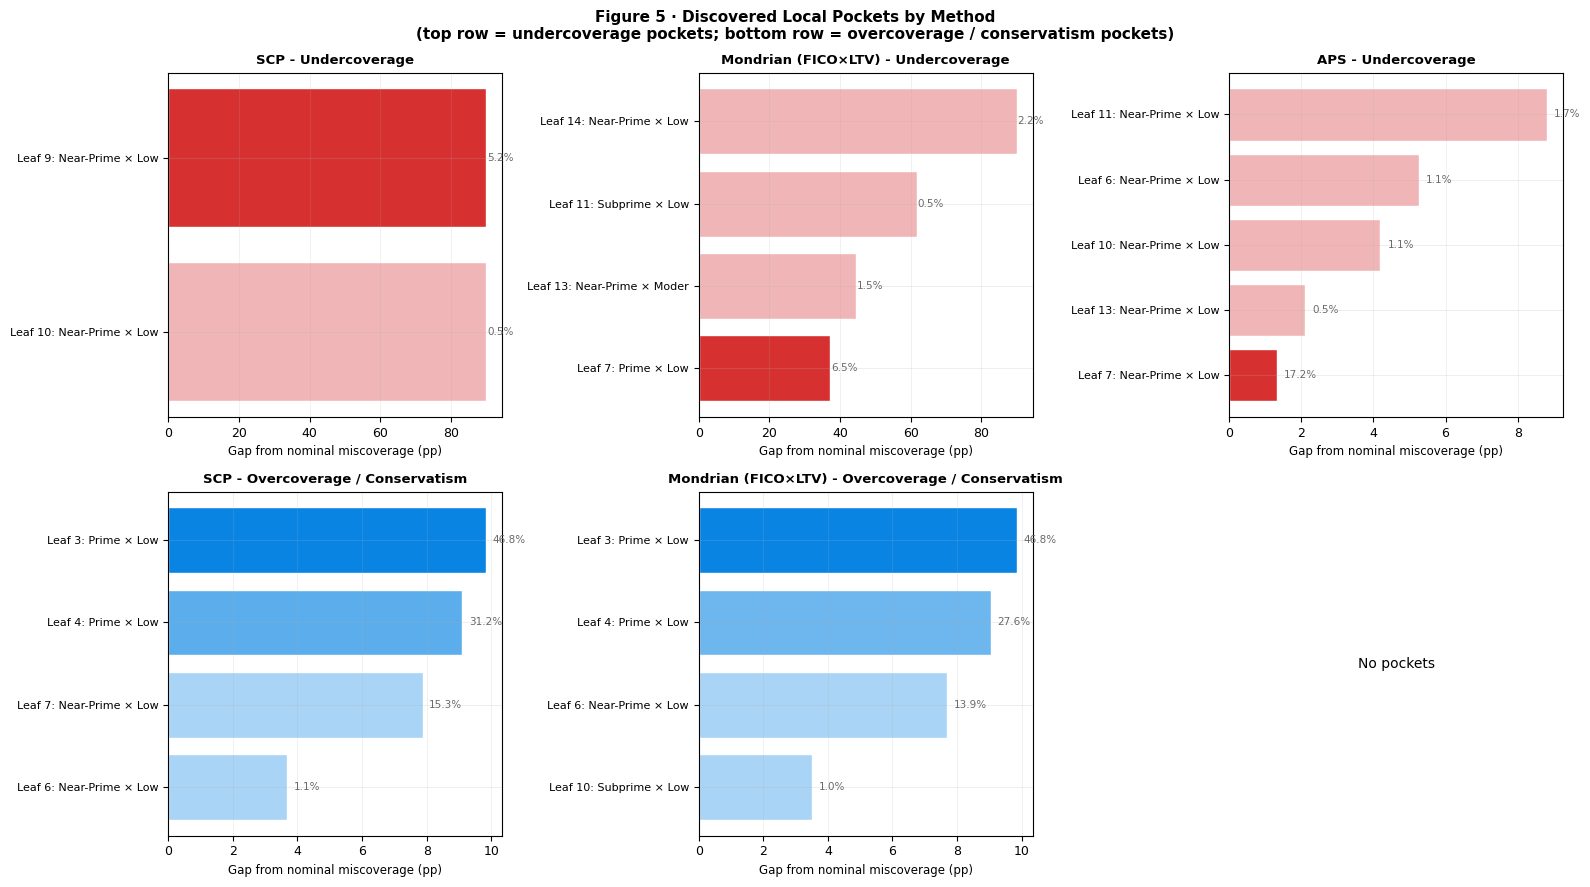

Figure 5 saved.


In [ ]:
# ── Figure 5: One-sided local pockets by method ───────────────────────────
#
# Two rows:
#   Row 1 = top undercoverage pockets
#   Row 2 = top overcoverage / conservatism pockets
#
# Undercoverage and overcoverage pockets are shown separately because both
# directions of deviation matter in deployment.

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=False)
fig.suptitle(
    "Figure 5 · Discovered Local Pockets by Method\n"
    "(top row = undercoverage pockets; bottom row = overcoverage / conservatism pockets)",
    fontsize=11,
    fontweight="bold",
)

for j, method in enumerate(AUDIT_METHODS):
    pockets_m = all_pockets_df[all_pockets_df["method"] == method].copy()

    under = pockets_m[pockets_m["pocket_type"] == "undercoverage"].head(5)
    over = pockets_m[pockets_m["pocket_type"] == "overcoverage"].head(5)

    for row_idx, (subset, title_suffix, gap_col, color) in enumerate([
        (under, "Undercoverage", "under_gap_pp", "#d63031"),
        (over, "Overcoverage / Conservatism", "over_gap_pp", "#0984e3"),
    ]):
        ax = axes[row_idx, j]

        if len(subset) == 0:
            ax.text(0.5, 0.5, "No pockets", ha="center", va="center", fontsize=10)
            ax.set_axis_off()
            continue

        y_pos = np.arange(len(subset))
        vals = subset[gap_col].values
        labels = [
            f"Leaf {int(r['leaf_id'])}: {str(r['dominant_fico_ltv'])[:18]}"
            for _, r in subset.iterrows()
        ]
        support = subset["support_pct"].values

        alpha_vals = np.clip(support / support.max(), 0.35, 1.0)
        colors_bar = [(*mpl.colors.to_rgb(color), a) for a in alpha_vals]

        ax.barh(y_pos, vals, color=colors_bar, edgecolor="white")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("Gap from nominal miscoverage (pp)", fontsize=8.5)
        ax.set_title(
            f"{METHOD_LABELS[method]} - {title_suffix}",
            fontsize=9.5,
            fontweight="bold",
        )
        ax.grid(axis="x", alpha=0.25)

        for i, (_, r) in enumerate(subset.iterrows()):
            ax.text(
                vals[i] + 0.2,
                i,
                f"{r['support_pct']:.1f}%",
                va="center",
                ha="left",
                fontsize=7.5,
                color="dimgray",
            )

fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_local_pockets.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 5 saved.")

In [ ]:
# ── Data behind Figure 5 ────────────────────────────────────────────────────
fig5_data = (
    all_pockets_df
    .sort_values(["method", "pocket_type", "dev_from_nominal_miscov_pp"],
                 ascending=[True, True, False])
    .reset_index(drop=True)
)

print("Data behind Figure 5: plotted one-sided local pockets by method")
print(fig5_data.to_string(index=False))

Data behind Figure 5: plotted one-sided local pockets by method
           method  leaf_id    n_obs  support_pct  miscov_rate  miscov_rate_pct  coverage_rate  coverage_rate_pct  dev_from_nominal_miscov_pp  under_gap_pp  over_gap_pp  mean_p_hat_cal     dominant_fico_ltv dominant_regime dominant_fico   pocket_type
              aps       11  1576409     1.661657     0.188138        18.813836       0.811862          81.186164                    8.813836      8.813836     0.000000        0.115256      Near-Prime × Low      Tail Shift    Near-Prime undercoverage
              aps        6  1003043     1.057285     0.152621        15.262058       0.847379          84.737942                    5.262058      5.262058     0.000000        0.004649      Near-Prime × Low          Stable    Near-Prime undercoverage
              aps       10  1041348     1.097661     0.141917        14.191702       0.858083          85.808298                    4.191702      4.191702     0.000000        0.033827   

---
## Section 6 · Segment Taxonomy: Discovered vs Predefined Group Overlap

This section asks whether the discovered pockets align with the predefined FICO×LTV
cells or cut across them.

Two types of pockets are reported:

1. **Undercoverage pockets:** empirical miscoverage above $\alpha=10\%$.
2. **Overcoverage / conservatism pockets:** empirical miscoverage below $\alpha$.

For each pocket, §6.1 reports its largest FICO×LTV-cell share, largest regime share,
and largest joint FICO×LTV × regime share.

The legacy `taxonomy_explained` flag applies a 60% cutoff **only to the joint
cell×regime share**. It is therefore an exploratory joint-composition heuristic,
not a test of whether FICO×LTV alone explains the pocket. FICO×LTV relevance is read
from the cell concentrations together with the cell-level coverage and pooled
feature-gain diagnostics; no formal hypothesis decision is attached to the 60% flag.

The pooled gain results also do not support a primarily temporal interpretation:
`p_hat_cal` carries most gain for SCP and APS, while Mondrian retains substantial
FICO/LTV-related gain. Individual regime shares are therefore descriptive pocket
composition, not evidence that regime is the dominant predictive dimension.


In [ ]:
# ── 6.1 · Pocket-taxonomy overlap analysis ────────────────────────────────
# Overlap is evaluated per pocket type (undercoverage / overcoverage).

TAXONOMY_THRESHOLD = 0.60

overlap_rows = []
X_all = df_pd[TREE_FEATURES].values.astype(np.float32)

for method in AUDIT_METHODS:
    leaf_ids = trees[method].apply(X_all.astype(np.float32))
    pockets_m = all_pockets_df[all_pockets_df["method"] == method].copy()

    print(f"\n{'='*78}")
    print(f"{METHOD_LABELS[method]} - Pocket Taxonomy Analysis")
    print(f"{'='*78}")

    for _, pocket in pockets_m.iterrows():
        lid = int(pocket["leaf_id"])
        pocket_type = pocket["pocket_type"]

        mask = leaf_ids == lid
        sub = df_pd.loc[mask].copy()
        if len(sub) == 0:
            continue

        cell_counts = sub["fico_ltv_group"].value_counts(normalize=True) * 100
        reg_counts = sub["regime"].value_counts(normalize=True) * 100

        top_cell = cell_counts.index[0]
        top_cell_frac = float(cell_counts.iloc[0])

        top_regime = reg_counts.index[0]
        top_regime_frac = float(reg_counts.iloc[0])

        sub["cell_regime"] = sub["fico_ltv_group"] + " | " + sub["regime"]
        cr_counts = sub["cell_regime"].value_counts(normalize=True) * 100
        top_cr = cr_counts.index[0]
        top_cr_frac = float(cr_counts.iloc[0])

        taxonomy_explained = top_cr_frac >= TAXONOMY_THRESHOLD * 100

        print(
            f"  Leaf {lid:>3d} | {pocket_type:<13} | "
            f"miscov={pocket['miscov_rate_pct']:.2f}% | "
            f"support={pocket['support_pct']:.2f}%"
        )
        print(f"    Top FICO×LTV     : {top_cell:<30} ({top_cell_frac:.1f}%)")
        print(f"    Top regime       : {top_regime:<30} ({top_regime_frac:.1f}%)")
        print(f"    Top cell×regime  : {top_cr:<40} ({top_cr_frac:.1f}%)")
        print(
            f"    Taxonomy-explained (≥{TAXONOMY_THRESHOLD*100:.0f}%): "
            f"{'YES' if taxonomy_explained else 'NO - cross-cutting'}"
        )
        print()

        overlap_rows.append({
            "method": method,
            "leaf_id": lid,
            "pocket_type": pocket_type,
            "miscov_rate_pct": pocket["miscov_rate_pct"],
            "coverage_rate_pct": pocket["coverage_rate_pct"],
            "support_pct": pocket["support_pct"],
            "top_fico_ltv": top_cell,
            "top_fico_ltv_pct": top_cell_frac,
            "top_regime": top_regime,
            "top_regime_pct": top_regime_frac,
            "top_cell_regime": top_cr,
            "top_cell_regime_pct": top_cr_frac,
            "taxonomy_explained": taxonomy_explained,
        })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(NB08_OUT_DIR / "nb08_pocket_overlap.csv", index=False)

print()

summary_overlap = (
    overlap_df.groupby(["method", "pocket_type"])["taxonomy_explained"]
    .agg(["sum", "count"])
    .reset_index()
)
print(summary_overlap.to_string(index=False))


SCP - Pocket Taxonomy Analysis
  Leaf   9 | undercoverage | miscov=100.00% | support=5.21%
    Top FICO×LTV     : Near-Prime × Low               (30.8%)
    Top regime       : Tail Shift                     (49.6%)
    Top cell×regime  : Near-Prime × Low | Tail Shift            (16.0%)
    Taxonomy-explained (≥60%): NO - cross-cutting

  Leaf  10 | undercoverage | miscov=100.00% | support=0.52%
    Top FICO×LTV     : Near-Prime × Low               (31.4%)
    Top regime       : Tail Shift                     (51.7%)
    Top cell×regime  : Near-Prime × Low | Tail Shift            (16.2%)
    Taxonomy-explained (≥60%): NO - cross-cutting

  Leaf   3 | overcoverage  | miscov=0.15% | support=46.79%
    Top FICO×LTV     : Prime × Low                    (86.0%)
    Top regime       : Stable                         (41.2%)
    Top cell×regime  : Prime × Low | Stable                     (34.8%)
    Taxonomy-explained (≥60%): NO - cross-cutting

  Leaf   4 | overcoverage  | miscov=0.89% | supp

---
## Section 7 · Method-Level Local Interpretation

This section synthesises the local reliability diagnostics without treating their
AUROC levels or score-only -> full increments as a common cross-method effect size.

### Risk-decile table

Coverage is profiled across deciles of **predicted miscoverage risk** on the held-out
evaluation-year observations. Because the pooled reliability model is evaluated on
2019, 2022, and 2023, this diagnostic covers the Normal-window tail and Rate-Hike
window; the leave-one-regime-out AUROC analysis in §3 covers all four regimes.

A strong low-to-high predicted-risk gradient indicates that the fitted reliability
model localises realised failure. A flatter profile indicates weaker concentration.

### APS score-band diagnostic

Section 7.2 separately compares APS miscoverage below and above a calibrated
probability of 5%. The residual weakness is in the **higher-risk (`p_hat_cal >= 5%`)**
region, where miscoverage exceeds the corresponding below-5% rate in every regime.

### Interpretation

In pooled gain, `p_hat_cal` dominates SCP and APS, while Mondrian also carries
substantial FICO/LTV-related structure. The discovered pockets can cut across
cell×regime combinations, but neither the pocket composition nor the gain diagnostic
is interpreted as a formal conditional-validity test.

In [ ]:
# ── 7.1 · Risk-decile coverage tables per method and regime ─────────────────
#
# For each (method, regime), sort observations by predicted miscoverage risk,
# bin into deciles, and compute empirical coverage in each decile.
# The gradient reveals whether the reliability model identifies locally
# unreliable observations beyond what marginal subgroup summaries show.

print("=== Risk-Decile Coverage by Method and Regime ===\n")
print(f"{'Method':<24} {'Regime':<20} {'D1(safe)':>9} {'D5':>7} {'D10(risky)':>10} "
      f"{'Δ D10-D1':>10} {'AUROC':>7}")
print("-" * 90)

rd_rows = []
for method in AUDIT_METHODS:
    mc_col   = M_COLS[method]
    risk_col = f"risk_{method}"

    for split in TEST_SPLITS:
        # Eval-year (OOS) rows only; see §4.1 for the rationale. Regimes with no
        # eval-year rows are skipped by the len check below.
        sub = df_pd[(df_pd["split"] == split) & (df_pd["is_eval"])].copy()
        if len(sub) < 200:
            continue

        y_mc   = sub[mc_col].values
        y_risk = sub[risk_col].values

        # Decile by risk
        decile_labels = pd.qcut(y_risk, 10, labels=False, duplicates="drop")
        cov_by_decile = {}
        for d in range(10):
            mask = decile_labels == d
            if mask.sum() < 10:
                continue
            cov_by_decile[d+1] = (1 - y_mc[mask].mean()) * 100

        d1   = cov_by_decile.get(1, np.nan)
        d5   = cov_by_decile.get(5, np.nan)
        d10  = cov_by_decile.get(10, np.nan)
        delta = (d10 - d1) if not (np.isnan(d1) or np.isnan(d10)) else np.nan

        try:
            auroc = roc_auc_score(y_mc, y_risk) if y_mc.sum() > 10 else np.nan
        except Exception:
            auroc = np.nan

        print(f"  {METHOD_LABELS[method]:<22} {SPLIT_LABELS[split]:<20} "
              f"{d1:>9.2f}% {d5:>7.2f}% {d10:>10.2f}% "
              f"{delta:>+10.2f}pp {auroc:>7.4f}")

        for d, cov in cov_by_decile.items():
            rd_rows.append({
                "method": method, "split": split, "mechanism": SPLIT_MECH[split],
                "decile": d, "coverage_pct": cov, "auroc": auroc,
            })

=== Risk-Decile Coverage by Method and Regime ===

Method                   Regime                D1(safe)      D5 D10(risky)   Δ D10-D1   AUROC
------------------------------------------------------------------------------------------
  SCP                    Normal (2013–19)        100.00%   99.98%      46.92%     -53.08pp  0.9839
  SCP                    Rate Hike (2022–23)     100.00%  100.00%      64.98%     -35.02pp  0.9948
  Mondrian (FICO×LTV)    Normal (2013–19)        100.00%  100.00%      41.66%     -58.34pp  0.9862
  Mondrian (FICO×LTV)    Rate Hike (2022–23)     100.00%  100.00%      53.90%     -46.10pp  0.9964
  APS                    Normal (2013–19)         91.25%   89.92%      74.58%     -16.67pp  0.5897
  APS                    Rate Hike (2022–23)      91.13%   90.02%      84.72%      -6.42pp  0.5366


In [ ]:
# ── 7.2 · APS score-band diagnostic ────────────────────────────────────────

RISK_TAIL_THRESHOLD = 0.05  # descriptive split between lower- and higher-risk score regions

print("=== APS Low-Risk Tail Audit ===\n")

aps_tail_rows = []

for split in TEST_SPLITS:
    sub = df_pd[df_pd["split"] == split].copy()

    low_mask = sub["p_hat_cal"] < RISK_TAIL_THRESHOLD
    high_mask = ~low_mask

    low_miscov = float(sub.loc[low_mask, "m_aps"].mean()) if low_mask.sum() > 0 else np.nan
    high_miscov = float(sub.loc[high_mask, "m_aps"].mean()) if high_mask.sum() > 0 else np.nan
    all_miscov = float(sub["m_aps"].mean())

    print(f"{SPLIT_LABELS[split]}:")
    print(f"  Overall APS miscoverage: {all_miscov*100:.3f}%")
    print(f"  Low-risk tail  (p̂_cal < {RISK_TAIL_THRESHOLD*100:.0f}%):  "
          f"{low_miscov*100:.3f}%  (n={int(low_mask.sum()):,})")
    print(f"  Higher-risk tail (p̂_cal ≥ {RISK_TAIL_THRESHOLD*100:.0f}%): "
          f"{high_miscov*100:.3f}%  (n={int(high_mask.sum()):,})")

    if low_mask.sum() > 100:
        cell_miscov = (
            sub.loc[low_mask]
            .groupby("fico_ltv_group")["m_aps"]
            .agg(["mean", "count"])
            .sort_values("mean", ascending=False)
        )
        cell_miscov["miscov_pct"] = cell_miscov["mean"] * 100

        print("  Low-risk tail by FICO×LTV:")
        for cell, row in cell_miscov.iterrows():
            if row["count"] > 50 and cell != "Sentinel":
                print(f"    {cell:<30}: miscov={row['miscov_pct']:.3f}%  n={int(row['count']):,}")

        for cell, row in cell_miscov.reset_index().iterrows():
            aps_tail_rows.append({
                "split": split,
                "fico_ltv_group": row["fico_ltv_group"],
                "count": int(row["count"]),
                "miscov_rate": float(row["mean"]),
                "miscov_rate_pct": float(row["miscov_pct"]),
                "tail": "low_risk",
            })
    print()

aps_tail_df = pd.DataFrame(aps_tail_rows)

=== APS Low-Risk Tail Audit ===

Subprime (2007–12):
  Overall APS miscoverage: 11.008%
  Low-risk tail  (p̂_cal < 5%):  10.838%  (n=30,586,929)
  Higher-risk tail (p̂_cal ≥ 5%): 15.712%  (n=1,105,824)
  Low-risk tail by FICO×LTV:
    Subprime × High               : miscov=14.930%  n=37,427
    Near-Prime × High             : miscov=12.745%  n=188,143
    Subprime × Moderate           : miscov=12.152%  n=234,447
    Subprime × Low                : miscov=12.107%  n=1,086,816
    Near-Prime × Moderate         : miscov=11.879%  n=1,368,167
    Near-Prime × Low              : miscov=11.377%  n=6,978,693
    Prime × High                  : miscov=11.309%  n=302,244
    Prime × Moderate              : miscov=10.943%  n=2,021,851
    Prime × Low                   : miscov=10.417%  n=18,308,815

Normal (2013–19):
  Overall APS miscoverage: 10.539%
  Low-risk tail  (p̂_cal < 5%):  10.447%  (n=36,885,321)
  Higher-risk tail (p̂_cal ≥ 5%): 14.336%  (n=900,305)
  Low-risk tail by FICO×LTV:
    Su

In [ ]:
# ── 7.3 · One-sided local summary: undercoverage vs overcoverage ───────────
#
# Compact method-level summary separating the two directions of local
# reliability deviation, with each method's LOSO score-only/full ΔAUROC.

one_sided_rows = []

for method in AUDIT_METHODS:
    segs = all_segments_df[all_segments_df["method"] == method].copy()

    # Worst undercoverage pocket
    under = segs[segs["under_gap_pp"] > 0].sort_values(
        ["under_gap_pp", "support_pct"], ascending=[False, False]
    )
    if len(under) > 0:
        u = under.iloc[0]
    else:
        u = None

    # Worst overcoverage pocket
    over = segs[segs["over_gap_pp"] > 0].sort_values(
        ["over_gap_pp", "support_pct"], ascending=[False, False]
    )
    if len(over) > 0:
        o = over.iloc[0]
    else:
        o = None

    loso_m = loso_df[loso_df["method"] == method]
    score_auc = loso_m[loso_m["feat_set"] == "score_only"]["auroc"].mean()
    full_auc = loso_m[loso_m["feat_set"] == "full"]["auroc"].mean()
    delta_auc = full_auc - score_auc

    one_sided_rows.append({
        "method": method,
        "method_label": METHOD_LABELS[method],
        "score_only_auroc": score_auc,
        "full_feature_auroc": full_auc,
        "delta_auroc": delta_auc,
        "worst_under_gap_pp": np.nan if u is None else float(u["under_gap_pp"]),
        "worst_under_support_pct": np.nan if u is None else float(u["support_pct"]),
        "worst_under_cell": None if u is None else u["dominant_fico_ltv"],
        "worst_under_regime": None if u is None else u["dominant_regime"],
        "worst_over_gap_pp": np.nan if o is None else float(o["over_gap_pp"]),
        "worst_over_support_pct": np.nan if o is None else float(o["support_pct"]),
        "worst_over_cell": None if o is None else o["dominant_fico_ltv"],
        "worst_over_regime": None if o is None else o["dominant_regime"],
    })

one_sided_df = pd.DataFrame(one_sided_rows)
one_sided_df.to_csv(NB08_OUT_DIR / "nb08_one_sided_summary.csv", index=False)
print(one_sided_df.to_string(index=False))

           method        method_label  score_only_auroc  full_feature_auroc  delta_auroc  worst_under_gap_pp  worst_under_support_pct worst_under_cell worst_under_regime  worst_over_gap_pp  worst_over_support_pct worst_over_cell worst_over_regime
              scp                 SCP          0.994897            0.995191     0.000294           90.000000                 5.207088 Near-Prime × Low         Tail Shift            9.85149               46.791366     Prime × Low            Stable
mondrian_fico_ltv Mondrian (FICO×LTV)          0.953005            0.995086     0.042081           89.984944                 2.226387 Near-Prime × Low         Tail Shift            9.85149               46.791366     Prime × Low            Stable
              aps                 APS          0.554649            0.552827    -0.001822            8.813836                 1.661657 Near-Prime × Low         Tail Shift                NaN                     NaN            None              None


---
## Section 8 · Locked Findings

This section consolidates the NB08 empirical results into a structured diagnostic assessment. The stored printout below retains legacy `hypothesis assessment` and `explained`
labels.

### Diagnostic caveat
NB08 does not claim exact conditional validity. The learned reliability models and
shallow-tree segments are descriptive audit tools. They identify where miscoverage is
locally concentrated, but they do not provide distribution-free guarantees of the type
produced by the conformal calibration in NB05b.

This distinction matters because conformal prediction provides finite-sample
marginal validity under exchangeability (Vovk et al., 2005; Papadopoulos et al.,
2002), but distribution-free conditional coverage is impossible in any meaningful
finite-sample sense without additional assumptions (Lei & Wasserman, 2014;
Foygel Barber et al., 2021). The class-specific collapse of positive-class coverage
observed under SCP illustrates this gap: SCP can meet or exceed the marginal target
while severely undercovering the minority (delinquent) class - the majority-class
bias of unconditional conformal prediction on imbalanced data
(Löfström et al., 2015), which motivates label-conditional approaches (Vovk, 2012;
Sadinle et al., 2019) and the many-class treatment of Ding et al. (2023). Recent diagnostic work
therefore treats local coverage assessment as an empirical reliability-estimation
problem rather than as a new conformal guarantee (Braun et al., 2025; Zhou et al.,
2026).


In [ ]:
# ── 8.1 · Final NB08 hypothesis assessment ─────────────────────────────────
#
# Reads saved CSVs from Section 4 (feature importance), Section 6 (pocket overlap),
# and Section 7 (one-sided local summary) to produce a structured view of the results.

print("=" * 78)
print("NB08 FINAL HYPOTHESIS ASSESSMENT")
print("=" * 78)

fi_df = pd.read_csv(NB08_OUT_DIR / "nb08_feature_importance.csv")
ov_df = pd.read_csv(NB08_OUT_DIR / "nb08_pocket_overlap.csv")
one_df = pd.read_csv(NB08_OUT_DIR / "nb08_one_sided_summary.csv")

for method in AUDIT_METHODS:
    label = METHOD_LABELS[method]
    print(f"\n{label}")
    print("-" * len(label))

    # Feature-importance view.
    fi_m = fi_df[fi_df["method"] == method]

    def _gain(feat):
        v = fi_m.loc[fi_m["feature"] == feat, "gain_pct"]
        return float(v.iloc[0]) if len(v) else 0.0

    p_hat_gain    = _gain("p_hat_cal")
    fico_ltv_gain = _gain("fico_ltv_enc")
    taxonomy_gain = _gain("fico_tier_enc") + _gain("ltv_bucket_enc") + _gain("fico_ltv_enc")

    # AUROC view
    row = one_df[one_df["method"] == method].iloc[0]

    print(f"  Score-only AUROC         : {row['score_only_auroc']:.4f}")
    print(f"  Full-feature AUROC       : {row['full_feature_auroc']:.4f}")
    print(f"  ΔAUROC(full - score)     : {row['delta_auroc']:+.4f}")
    print(f"  Feature gain p̂_cal              : {p_hat_gain:.1f}%")
    print(f"  Feature gain FICO×LTV cell       : {fico_ltv_gain:.1f}%")
    print(f"  Feature gain FICO×LTV (aggregate): {taxonomy_gain:.1f}%")

    print(f"  Worst undercoverage gap  : {row['worst_under_gap_pp']:.2f}pp "
          f"(support {row['worst_under_support_pct']:.2f}%, "
          f"cell={row['worst_under_cell']}, regime={row['worst_under_regime']})")
    print(f"  Worst overcoverage gap   : {row['worst_over_gap_pp']:.2f}pp "
          f"(support {row['worst_over_support_pct']:.2f}%, "
          f"cell={row['worst_over_cell']}, regime={row['worst_over_regime']})")

    ov_m = ov_df[ov_df["method"] == method]
    tax_summary = (
        ov_m.groupby("pocket_type")["taxonomy_explained"]
        .agg(["sum", "count"])
        .reset_index()
    )
    if len(tax_summary):
        print("  Taxonomy overlap:")
        for _, r in tax_summary.iterrows():
            print(f"    {r['pocket_type']:<13}: {int(r['sum'])}/{int(r['count'])} explained")

print()
print("=" * 78)
print("NB08 Final Output Complete")
print("=" * 78)

NB08 FINAL HYPOTHESIS ASSESSMENT

SCP
---
  Score-only AUROC         : 0.9949
  Full-feature AUROC       : 0.9952
  ΔAUROC(full - score)     : +0.0003
  Feature gain p̂_cal              : 93.5%
  Feature gain FICO×LTV cell       : 3.4%
  Feature gain FICO×LTV (aggregate): 5.6%
  Worst undercoverage gap  : 90.00pp (support 5.21%, cell=Near-Prime × Low, regime=Tail Shift)
  Worst overcoverage gap   : 9.85pp (support 46.79%, cell=Prime × Low, regime=Stable)
  Taxonomy overlap:
    overcoverage : 0/4 explained
    undercoverage: 0/2 explained

Mondrian (FICO×LTV)
-------------------
  Score-only AUROC         : 0.9530
  Full-feature AUROC       : 0.9951
  ΔAUROC(full - score)     : +0.0421
  Feature gain p̂_cal              : 70.0%
  Feature gain FICO×LTV cell       : 8.9%
  Feature gain FICO×LTV (aggregate): 29.3%
  Worst undercoverage gap  : 89.98pp (support 2.23%, cell=Near-Prime × Low, regime=Tail Shift)
  Worst overcoverage gap   : 9.85pp (support 46.79%, cell=Prime × Low, regime=Stab

In [ ]:
# ── 8.2 · Write NB08 output manifest ─────────────────────────────────────

if "RISK_TAIL_THRESHOLD" not in dir():
    RISK_TAIL_THRESHOLD = 0.05

nb08_manifest = {
    "aps_risk_tail_threshold": RISK_TAIL_THRESHOLD,
}

manifest_path = MANIFEST_DIR / "audit_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(nb08_manifest, f, indent=2)

print("NB08 output manifest written:")
print(f"  {manifest_path}")

NB08 output manifest written:
  /content/drive/MyDrive/master_thesis/manifests/audit_manifest.json


## Appendix · References

---

### Conformal Prediction - Foundations

- Papadopoulos, H., Proedrou, K., Vovk, V., & Gammerman, A. (2002). Inductive confidence machines for regression. In T. Elomaa, H. Mannila, & H. Toivonen (Eds.), Machine learning: Ecml 2002 (pp. 345–356, Vol. 2430). Springer. https://doi.org/10.1007/3-540-36755-1_29

- Vovk, V., Gammerman, A., & Shafer, G. (2005). Algorithmic learning in a random world (1st ed.). Springer. https://doi.org/10.1007/b106715

- Lei, J., & Wasserman, L. (2014). Distribution-free prediction bands for non-parametric regression. Journal of the Royal Statistical Society Series B: Statistical Methodology, 76(1), 71–96. https://doi.org/10.1111/rssb.12021

---

### APS (Adaptive Prediction Sets / GIQ Score)

- Romano, Y., Sesia, M., & Candès, E. J. (2020). Classification with valid and adaptive coverage. In H. Larochelle, M. Ranzato, R. Hadsell, M.-F. Balcan, & H.-T. Lin (Eds.), Advances in neural information processing systems (pp. 3581–3591, Vol. 33). Curran Associates, Inc. https://proceedings.neurips.cc/paper/2020/hash/244edd7e85dc81602b7615cd705545f5-Abstract.html

- Sadinle, M., Lei, J., & Wasserman, L. (2019). Least ambiguous set-valued classifiers with bounded error levels. Journal of the American Statistical Association, 114(525), 223–234. https://doi.org/10.1080/01621459.2017.1395341

---

### Mondrian Conformal Prediction

- Vovk, V. (2012). Conditional validity of inductive conformal predictors. In S. C. H. Hoi & W. Buntine (Eds.), Proceedings of the asian conference on machine learning (pp. 475–490, Vol. 25). PMLR. https://proceedings.mlr.press/v25/vovk12.html

---

### Conditional Coverage and Class-Conditional Diagnostics

- Löfström, T., Boström, H., Linusson, H., & Johansson, U. (2015). Bias reduction through conditional
conformal prediction. Intelligent Data Analysis, 19(6), 1355–1375. https://doi.org/10.3233/IDA-150786

- Ding, T., Angelopoulos, A. N., Bates, S., Jordan, M. I., & Tibshirani, R. J. (2023). Class-conditional
conformal prediction with many classes. In A. Oh, T. Naumann, A. Globerson, K. Saenko,
M. Hardt, & S. Levine (Eds.), Advances in neural information processing systems (pp. 64555–
64576, Vol. 36). Curran Associates, Inc. https://doi.org/10.52202/075280-2817

- Foygel Barber, R., Candès, E. J., Ramdas, A., & Tibshirani, R. J. (2021). The limits of distribution-free
conditional predictive inference. Information and Inference: A Journal of the IMA, 10(2), 455–482. https://doi.org/10.1093/imaiai/iaaa017

---

### Local Validity as a Supervised-Learning Problem

- Braun, S., Holzmüller, D., Jordan, M. I., & Bach, F. (2025). Conditional coverage diagnostics for confor-
mal prediction. arXiv: 2512.11779 [stat.ML]. https://doi.org/10.48550/arXiv.2512.11779

- Zhou, Z., Zhang, X., Tao, C., & Yang, Y. (2026, April 23). Conformal prediction assessment: A framework
for conditional coverage evaluation and selection. arXiv: 2603.27189v2 [stat.ME]. https://doi.org/10.48550/arXiv.2603.27189

---

### Reliability and Calibration Diagnostics

- Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. Proceedings of the 22nd International Conference on Machine Learning, 625–632. https://doi.org/10.1145/1102351.1102430

- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. In D. Precup & Y. W. Teh (Eds.), Proceedings of the 34th international conference on machine learning (pp. 1321–1330, Vol. 70). PMLR. https://proceedings.mlr.press/v70/guo17a.html

---

### Machine Learning Methods

- Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. Advances in Neural Information Processing Systems, 30, 3146–3154. https://proceedings.neurips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b7Abstract.html

- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). Classification and regression trees. Wadsworth International Group.

---

### Population Stability Index and Credit-Risk Monitoring

- Yurdakul, B., & Naranjo, J. D. (2020). Statistical properties of the population stability index. Journal
of Risk Model Validation, 14(4), 89–100. https://doi.org/10.21314/JRMV.2020.227